# Estados de saturación CL por grade: affected, zoom-in y heatmaps ORA

Este notebook ejecuta directamente en BigQuery la reconstrucción event-driven para **ayer**, usando todos los restaurant vendors de Chile y agregando nacionalmente por grade.

1. **Curva XYZ affected por grade**: cotas mínimas de saturación en orden ascendente.
2. **Zoom-in por componente**: queued orders, riders near pickup y AWT máximo entre 0 y 9.
3. **Heatmaps ORA condicionados**: fija una componente del trigger y cruza las otras dos.
4. **Simulador healthy vs affected**: compara ambos universos para cualquier combinación `XYZ`.

El orden ORA/XYZ siempre es `queued orders / riders near pickup / AWT máximo completado`.

- **Affected**: `queued_orders >= X AND riders_near_pu >= Y AND AWT >= Z`.
- **Healthy**: el complemento; al menos una componente queda bajo su cota.

`000` contiene el 100% del universo. Al subir una cota, el volumen affected sólo puede mantenerse o disminuir.

### Dos conceptos distintos de AWT

- **Z del estado**: máximo AWT en vivo reconstruido desde transiciones. Incluye intentos intermedios y sólo determina cuándo cambia el estado de saturación.
- **AWT mostrado como resultado**: AWT final oficial de las orders con AWT, calculado como `SUM(awt_total_minutes) / SUM(awt_orders)`.


## 1. Imports y configuración

In [1]:
from datetime import date, timedelta
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, clear_output, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=0.95,
)

warnings.filterwarnings("ignore", message="All-NaN slice encountered")



# =========================================================
# FILTROS GENERALES
# None incluye todos. También acepta listas, por ejemplo ["A", "AA"].
# =========================================================

FRANCHISE_FILTER = None
GRADE_FILTER = None


# =========================================================
# CURVAS AFFECTED
# =========================================================

# Se busca el primer límite XYZ cuyo universo healthy cubra al menos
# este share. El residual affected será <= 100 - target.
TARGET_HEALTHY_ORDER_SHARE_PCT = 95.0

# Muestra hasta 12 cotas XYZ en orden ascendente; la última es XYZ+.
AFFECTED_POINTS = 12

# El zoom-in usa estas cotas mínimas inclusivas. 0 representa 100%.
ZOOM_MIN_THRESHOLD = 0
ZOOM_MAX_THRESHOLD = 9

# Oculta outcomes inestables, pero mantiene share y cantidad de orders.
MIN_ORDERS_LINE = 30

# La consulta usa CURRENT_DATE() - 1 día.
YESTERDAY = date.today() - timedelta(days=1)
DATES_TEXT = YESTERDAY.strftime("%d/%m/%Y")

# Opcional: vendors exactos por grade cuando la tabla agregada no los trae.
# Ejemplo: {"AAA": 120, "AA": 95, "A": 80}
VENDORS_BY_GRADE = {}

GRADE_ORDER = ["AAA", "AA", "A", "B", "C", "D"]

COLORS = {
    "seamless": "#171028",
    "orders_share": "#8B8B93",
    "awt": "#F53B4B",
    "pickup": "#00A878",
    "hdm": "#4179F2",
    "healthy": "#43A66B",
    "affected": "#E45B64",
}

BACKGROUND = "#F4F4F6"


# =========================================================
# EXPLORADOR ORA CONDICIONADO
# Ejemplo inicial: Grade AA y queued orders >= 1.
# `minimum` mantiene la lógica del trigger; `exact` sirve para diagnóstico.
# =========================================================

ORA_DEFAULT_GRADE = "AA"
ORA_DEFAULT_FRANCHISE = "ALL"
ORA_DEFAULT_FIXED_COMPONENT = "queued_orders"
ORA_DEFAULT_FIXED_VALUE = 1
ORA_DEFAULT_FIXED_MODE = "minimum"  # "minimum" o "exact"
ORA_MIN_THRESHOLD = 0
ORA_MAX_THRESHOLD = 9


# =========================================================
# SIMULADOR: cotas mínimas affected iniciales
# =========================================================

SIM_DEFAULT_QUEUED_ORDERS = 2
SIM_DEFAULT_RIDERS_NEAR_PU = 1
SIM_DEFAULT_AWT_MINUTES = 1


## 2. Consulta BigQuery: ayer, todo CL y agregación por grade

La consulta usa tablas temporales, por lo que debe ejecutarse completa como un script. `franchise_name` queda fija en `ALL_CL` únicamente para mantener compatibilidad con los gráficos del notebook.


In [29]:
try:
    from google.colab import auth
    auth.authenticate_user()
except ImportError:
    pass


query = r"""
-- ============================================================================
-- EVENT-DRIVEN SATURATION STATES | BigQuery / GoogleSQL SCRIPT
--
-- IMPORTANT:
--   Run the complete file as a BigQuery multi-statement script.
--   Heavy stages are materialized as TEMP TABLES to prevent the planner from
--   expanding the same CTE tree repeatedly. TEMP TABLES disappear when the
--   script finishes; only the final SELECT is returned.
--
-- Final grain:
--   grade x queued_orders x riders_near_pu x max_awt_completed_minutes
--
-- Scope:
--   All restaurant vendors in Chile, aggregated nationally by grade.
--
-- Attribution:
--   An order created at T is attributed to the state at T - 1 microsecond.
--
-- Live AWT used by the state timeline:
--   committed_pickup_at = COALESCE(original scheduled pickup,
--                                  updated scheduled pickup)
--   awt_start_at = GREATEST(committed_pickup_at, near_pickup_at)
--   awt_end_at   = next transition, pickup, cancellation or analysis end
--
-- Outcome definitions:
--   final AWT          = timings.avoidable_wait_time
--   total observed AWT = sum of all reconstructed rider-attempt intervals
--   previous/lost AWT = intervals that do not contain the final pickup
--   pickup time        = final pickup - order created_at_local
-- ============================================================================


-- ==========================================================================
-- 0. PARAMETERS
-- First iteration: yesterday only.
-- ==========================================================================

DECLARE analysis_start_date DATE DEFAULT DATE_SUB(CURRENT_DATE(), INTERVAL 7 DAY);
-- Para probar 7 días completos hasta ayer, cambia sólo el 1 anterior por 7.
DECLARE analysis_end_date DATE DEFAULT DATE_SUB(CURRENT_DATE(), INTERVAL 1 DAY);

DECLARE analysis_start_at DATETIME DEFAULT DATETIME(
  analysis_start_date,
  TIME '00:00:00'
);

DECLARE analysis_end_at DATETIME DEFAULT DATETIME(
  DATE_ADD(analysis_end_date, INTERVAL 1 DAY),
  TIME '00:00:00'
);

DECLARE source_start_date DATE DEFAULT DATE_SUB(
  analysis_start_date,
  INTERVAL 1 DAY
);


-- ==========================================================================
-- 1. ORDER SCOPE AND OUTCOME LOOKUPS
-- ==========================================================================

CREATE TEMP TABLE tmp_vendor_grades
CLUSTER BY vendor_code AS
SELECT
  SAFE_CAST(v.vendor_code AS INT64) AS vendor_code,
  ve.vendor_monitor.vendor_grade AS grade
FROM `fulfillment-dwh-production.curated_data_shared_vendor.growth_vendors` AS v
LEFT JOIN UNNEST(v.vendor) AS ve
WHERE v.entity_id = 'PY_CL'
  AND ve.is_latest
  AND ve.is_active
  AND v.vendor_code IS NOT NULL
QUALIFY ROW_NUMBER() OVER (
  PARTITION BY SAFE_CAST(v.vendor_code AS INT64)
  ORDER BY DATE(ve.vendor_monitor.last_updated_at) DESC
) = 1;


-- One row per order in the national restaurant/date scope.
-- Keeping the nested deliveries array here avoids rescanning the fact table.
CREATE TEMP TABLE tmp_orders_scope
CLUSTER BY vendor_code AS
SELECT
  l.peya_order_id,
  SAFE_CAST(l.vendor.vendor_code AS INT64) AS vendor_code,
  CAST(l.vendor.vendor_code AS STRING) AS store_name,
  'ALL_CL' AS franchise_name,
  COALESCE(vg.grade, 'NO_GRADE') AS grade,
  l.created_at_local,
  l.order_status,
  COALESCE(
    l.original_scheduled_pickup_at_local,
    l.updated_scheduled_pickup_at_local
  ) AS committed_pickup_at,
  l.deliveries,
  SAFE_DIVIDE(SAFE_CAST(l.estimated_prep_time AS FLOAT64), 60)
    AS ept_minutes,
  IF(
    l.timings.avoidable_wait_time IS NULL,
    NULL,
    SAFE_DIVIDE(
      GREATEST(SAFE_CAST(l.timings.avoidable_wait_time AS INT64), 0),
      60
    )
  ) AS final_awt_minutes
FROM `peya-bi-tools-pro.il_logistics.fact_logistic_orders` AS l
LEFT JOIN tmp_vendor_grades AS vg
  ON SAFE_CAST(l.vendor.vendor_code AS INT64) = vg.vendor_code
WHERE l.country_code = 'cl'
  AND l.created_date_local BETWEEN source_start_date AND analysis_end_date
  AND l.peya_order_id IS NOT NULL
  AND l.vendor.vertical_type = 'restaurants';


CREATE TEMP TABLE tmp_hdm AS
SELECT
  SAFE_CAST(gvo.order_code AS INT64) AS order_code,
  LOGICAL_OR(COALESCE(gvo.high_demand_mode.is_hd_order, FALSE))
    AS is_hd_order,
  MAX(
    IF(
      gvo.high_demand_mode.is_hd_order,
      COALESCE(
        SAFE_CAST(gvo.high_demand_mode.minutes_added AS FLOAT64),
        0
      ),
      0
    )
  ) AS hdm_minutes_added
FROM `fulfillment-dwh-production.curated_data_shared_vendor.growth_vendor_orders` AS gvo
INNER JOIN tmp_orders_scope AS scope
  ON scope.peya_order_id = SAFE_CAST(gvo.order_code AS INT64)
WHERE gvo.country_code = 'cl'
  AND gvo.created_date BETWEEN source_start_date AND analysis_end_date
  AND gvo.requested_pickup_at IS NULL
GROUP BY SAFE_CAST(gvo.order_code AS INT64);


-- Weighted AWT10 attribution; it can be fractional.
CREATE TEMP TABLE tmp_order_casuistics AS
SELECT
  CAST(n.order_id AS STRING) AS order_id,
  SAFE_CAST(n.partner_id AS INT64) AS vendor_code,
  SUM(
    IF(
      IFNULL(n.undispatch_reason, '') != 'Late Order Preparation',
      COALESCE(n.TR_STAFFING_AND_PARTNER_PERFO, 0) / 2
        + COALESCE(n.TR_STAFFING_RIDER_AND_PARTNER_PERFO, 0) / 3
        + COALESCE(n.TR_RIDER_AND_PARTNER_PERFO, 0) / 2
        + COALESCE(n.TR_PARTNER_PERFO, 0),
      0
    )
  ) AS awt10_attributed_orders
FROM `peya-delivery-and-support.automated_tables_reports.non_seamless_reasons` AS n
INNER JOIN tmp_orders_scope AS scope
  ON CAST(scope.peya_order_id AS STRING) = CAST(n.order_id AS STRING)
  AND scope.vendor_code = SAFE_CAST(n.partner_id AS INT64)
WHERE n.country_name = 'Chile'
  AND DATE(n.created_date_local)
    BETWEEN source_start_date AND analysis_end_date
GROUP BY order_id, vendor_code;


-- Collapse NS to one row per scoped order so it cannot multiply the fact row.
CREATE TEMP TABLE tmp_non_seamless_orders AS
SELECT
  ns.platform_order_code,
  LOGICAL_OR(COALESCE(ns.non_seamless_order, FALSE)) AS non_seamless,
  LOGICAL_OR(COALESCE(SAFE_CAST(ns.is_slow_order AS BOOL), FALSE))
    AS is_slow_order
FROM `peya-datamarts-pro.dm_fulfillment.non_seamless_delivery_order_level` AS ns
INNER JOIN tmp_orders_scope AS scope
  ON scope.peya_order_id = ns.platform_order_code
GROUP BY ns.platform_order_code;


CREATE TEMP TABLE tmp_orders_base AS
SELECT
  scope.*,
  COALESCE(ns.non_seamless, FALSE) AS non_seamless,
  COALESCE(ns.is_slow_order, FALSE) AS is_slow_order,
  ns.platform_order_code IS NOT NULL AS has_non_seamless_record,
  COALESCE(h.is_hd_order, FALSE) AS is_hd_order,
  COALESCE(h.hdm_minutes_added, 0) AS hdm_minutes_added,
  COALESCE(c.awt10_attributed_orders, 0) AS awt10_attributed_orders
FROM tmp_orders_scope AS scope
LEFT JOIN tmp_non_seamless_orders AS ns
  ON ns.platform_order_code = scope.peya_order_id
LEFT JOIN tmp_hdm AS h
  ON h.order_code = scope.peya_order_id
LEFT JOIN tmp_order_casuistics AS c
  ON c.order_id = CAST(scope.peya_order_id AS STRING)
  AND c.vendor_code = scope.vendor_code;


-- ==========================================================================
-- 2. ALL DELIVERY ATTEMPTS AND TRANSITIONS
-- ==========================================================================

CREATE TEMP TABLE tmp_delivery_attempts AS
SELECT
  ob.peya_order_id,
  ob.vendor_code,
  delivery.delivery_sk,
  delivery.delivery_id,
  delivery.rider_id,
  delivery.rider_picked_up_at_local,
  delivery.transitions
FROM tmp_orders_base AS ob
CROSS JOIN UNNEST(ob.deliveries) AS delivery
WHERE delivery.delivery_id IS NOT NULL
  AND COALESCE(delivery.is_returning, FALSE) = FALSE;


CREATE TEMP TABLE tmp_final_delivery_by_order AS
SELECT
  da.peya_order_id,
  da.delivery_id AS final_delivery_id,
  da.rider_id AS final_rider_id,
  da.rider_picked_up_at_local AS final_rider_picked_up_at
FROM tmp_delivery_attempts AS da
WHERE da.rider_picked_up_at_local IS NOT NULL
QUALIFY ROW_NUMBER() OVER (
  PARTITION BY da.peya_order_id
  ORDER BY da.rider_picked_up_at_local DESC, da.delivery_id DESC
) = 1;


CREATE TEMP TABLE tmp_delivery_transition_timeline
CLUSTER BY vendor_code, peya_order_id AS
SELECT
  da.peya_order_id,
  da.vendor_code,
  da.delivery_sk,
  da.delivery_id,
  da.rider_picked_up_at_local AS delivery_rider_picked_up_at,
  transition.transition_sk,
  transition.rider_id,
  transition.state,
  transition.undispatch_type,
  DATETIME(transition.created_at) AS transition_at,
  LEAD(DATETIME(transition.created_at)) OVER (
    PARTITION BY da.peya_order_id, da.delivery_id
    ORDER BY transition.created_at, transition.transition_sk
  ) AS next_transition_at
FROM tmp_delivery_attempts AS da
CROSS JOIN UNNEST(da.transitions) AS transition
WHERE transition.created_at IS NOT NULL;


-- Explicit order_cancelled is preferred. A generic cancelled state is used
-- only when the top-level order is cancelled, so reassignment does not close it.
CREATE TEMP TABLE tmp_order_cancel_times AS
SELECT
  ob.peya_order_id,
  COALESCE(
    MAX(IF(
      dtt.undispatch_type = 'order_cancelled',
      dtt.transition_at,
      NULL
    )),
    MAX(IF(
      LOWER(COALESCE(ob.order_status, '')) = 'cancelled'
        AND dtt.state = 'cancelled',
      dtt.transition_at,
      NULL
    ))
  ) AS order_cancelled_at
FROM tmp_orders_base AS ob
LEFT JOIN tmp_delivery_transition_timeline AS dtt
  USING (peya_order_id)
GROUP BY ob.peya_order_id;


-- Remove the deliveries array before the event/timeline stages.
CREATE TEMP TABLE tmp_orders_with_queue_end AS
SELECT
  ob.peya_order_id,
  ob.vendor_code,
  ob.store_name,
  ob.franchise_name,
  ob.grade,
  ob.created_at_local,
  ob.order_status,
  ob.committed_pickup_at,
  ob.non_seamless,
  ob.is_slow_order,
  ob.has_non_seamless_record,
  ob.ept_minutes,
  ob.final_awt_minutes,
  ob.is_hd_order,
  ob.hdm_minutes_added,
  ob.awt10_attributed_orders,
  fd.final_delivery_id,
  fd.final_rider_id,
  fd.final_rider_picked_up_at,
  oct.order_cancelled_at,
  ob.created_at_local AS queue_start_at,
  CASE
    WHEN fd.final_rider_picked_up_at IS NOT NULL
      THEN fd.final_rider_picked_up_at
    WHEN oct.order_cancelled_at IS NOT NULL
      THEN oct.order_cancelled_at
    WHEN LOWER(COALESCE(ob.order_status, '')) != 'cancelled'
      THEN analysis_end_at
    ELSE NULL
  END AS queue_end_at
FROM tmp_orders_base AS ob
LEFT JOIN tmp_final_delivery_by_order AS fd
  USING (peya_order_id)
LEFT JOIN tmp_order_cancel_times AS oct
  USING (peya_order_id);


CREATE TEMP TABLE tmp_orders_for_timeline
CLUSTER BY vendor_code, peya_order_id AS
SELECT
  peya_order_id,
  vendor_code,
  store_name,
  franchise_name,
  grade,
  committed_pickup_at,
  queue_start_at,
  queue_end_at,
  final_delivery_id,
  final_rider_id,
  final_rider_picked_up_at
FROM tmp_orders_with_queue_end
WHERE queue_end_at IS NOT NULL
  AND created_at_local < analysis_end_at
  AND queue_end_at > analysis_start_at
  AND queue_end_at > created_at_local;


CREATE TEMP TABLE tmp_completed_orders AS
SELECT
  peya_order_id,
  vendor_code,
  store_name,
  franchise_name,
  grade,
  created_at_local,
  non_seamless,
  is_slow_order,
  has_non_seamless_record,
  ept_minutes,
  final_awt_minutes,
  is_hd_order,
  hdm_minutes_added,
  awt10_attributed_orders,
  final_delivery_id,
  final_rider_id,
  final_rider_picked_up_at,
  SAFE_DIVIDE(
    DATETIME_DIFF(
      final_rider_picked_up_at,
      created_at_local,
      SECOND
    ),
    60
  ) AS pickup_time_minutes
FROM tmp_orders_with_queue_end
WHERE final_rider_picked_up_at IS NOT NULL
  AND created_at_local < analysis_end_at
  AND final_rider_picked_up_at > analysis_start_at
  AND final_rider_picked_up_at > created_at_local;


CREATE TEMP TABLE tmp_vendors_in_scope AS
SELECT DISTINCT
  vendor_code,
  store_name,
  franchise_name,
  grade
FROM tmp_orders_for_timeline;


-- ==========================================================================
-- 3. RIDER NEAR-PICKUP AND RECONSTRUCTED AWT INTERVALS
-- ==========================================================================

CREATE TEMP TABLE tmp_near_pickup_fragments AS
SELECT
  fragment.*
FROM (
  SELECT
    oft.vendor_code,
    oft.peya_order_id,
    dtt.delivery_sk,
    dtt.delivery_id,
    dtt.transition_sk,
    dtt.rider_id,
    oft.committed_pickup_at,
    oft.final_delivery_id,
    oft.final_rider_id,
    oft.final_rider_picked_up_at,
    GREATEST(
      dtt.transition_at,
      oft.queue_start_at
    ) AS near_start_at,
    LEAST(
      COALESCE(
        dtt.next_transition_at,
        dtt.delivery_rider_picked_up_at,
        oft.queue_end_at
      ),
      oft.queue_end_at
    ) AS near_end_at
  FROM tmp_delivery_transition_timeline AS dtt
  INNER JOIN tmp_orders_for_timeline AS oft
    USING (peya_order_id, vendor_code)
  WHERE dtt.state = 'near_pickup'
    AND dtt.rider_id IS NOT NULL
    AND dtt.transition_at IS NOT NULL
) AS fragment
WHERE fragment.near_end_at > fragment.near_start_at;


CREATE TEMP TABLE tmp_near_pickup_fragments_flagged AS
SELECT
  fragment_with_prior.*,
  IF(
    fragment_with_prior.prior_max_near_end_at IS NULL
      OR fragment_with_prior.prior_max_near_end_at
        < fragment_with_prior.near_start_at,
    1,
    0
  ) AS starts_new_near_interval
FROM (
  SELECT
    fragment.*,
    MAX(fragment.near_end_at) OVER (
      PARTITION BY
        fragment.peya_order_id,
        fragment.delivery_id,
        fragment.rider_id
      ORDER BY
        fragment.near_start_at,
        fragment.near_end_at,
        fragment.transition_sk
      ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
    ) AS prior_max_near_end_at
  FROM tmp_near_pickup_fragments AS fragment
) AS fragment_with_prior;


CREATE TEMP TABLE tmp_near_pickup_fragments_numbered AS
SELECT
  flagged.*,
  SUM(flagged.starts_new_near_interval) OVER (
    PARTITION BY
      flagged.peya_order_id,
      flagged.delivery_id,
      flagged.rider_id
    ORDER BY
      flagged.near_start_at,
      flagged.near_end_at,
      flagged.transition_sk
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
  ) AS near_interval_id
FROM tmp_near_pickup_fragments_flagged AS flagged;


CREATE TEMP TABLE tmp_rider_near_intervals
CLUSTER BY vendor_code, peya_order_id AS
SELECT
  vendor_code,
  peya_order_id,
  delivery_sk,
  delivery_id,
  rider_id,
  near_interval_id,
  committed_pickup_at,
  final_delivery_id,
  final_rider_id,
  final_rider_picked_up_at,
  MIN(near_start_at) AS near_start_at,
  MAX(near_end_at) AS near_end_at
FROM tmp_near_pickup_fragments_numbered
GROUP BY
  vendor_code,
  peya_order_id,
  delivery_sk,
  delivery_id,
  rider_id,
  near_interval_id,
  committed_pickup_at,
  final_delivery_id,
  final_rider_id,
  final_rider_picked_up_at;


CREATE TEMP TABLE tmp_awt_attempts_raw AS
SELECT
  rni.*,
  GREATEST(rni.committed_pickup_at, rni.near_start_at) AS awt_start_at
FROM tmp_rider_near_intervals AS rni
WHERE rni.committed_pickup_at IS NOT NULL;


-- Zero-AWT observations remain available for attempt counts and coverage.
CREATE TEMP TABLE tmp_awt_attempt_observations AS
SELECT
  raw.*,
  GREATEST(
    DATETIME_DIFF(raw.near_end_at, raw.awt_start_at, SECOND),
    0
  ) AS attempt_awt_seconds,
  raw.delivery_id = raw.final_delivery_id
    AND raw.rider_id = raw.final_rider_id
    AND raw.final_rider_picked_up_at >= raw.near_start_at
    AND raw.final_rider_picked_up_at <= raw.near_end_at
    AS is_final_pickup_attempt
FROM tmp_awt_attempts_raw AS raw;


-- Only positive intervals can be active or cross an integer-minute threshold.
CREATE TEMP TABLE tmp_awt_attempt_intervals
CLUSTER BY vendor_code, peya_order_id AS
SELECT *
FROM tmp_awt_attempt_observations
WHERE attempt_awt_seconds > 0;


CREATE TEMP TABLE tmp_awt_history_by_order AS
SELECT
  peya_order_id,
  COUNT(*) AS total_awt_attempts,
  SUM(attempt_awt_seconds) AS total_observed_awt_seconds,
  MAX(attempt_awt_seconds) AS max_observed_attempt_awt_seconds,
  COUNTIF(NOT is_final_pickup_attempt) AS previous_awt_attempts,
  SUM(IF(NOT is_final_pickup_attempt, attempt_awt_seconds, 0))
    AS previous_awt_seconds,
  MAX(IF(NOT is_final_pickup_attempt, attempt_awt_seconds, NULL))
    AS max_previous_awt_seconds,
  COUNTIF(is_final_pickup_attempt) AS reconstructed_final_awt_attempts,
  SUM(IF(is_final_pickup_attempt, attempt_awt_seconds, 0))
    AS reconstructed_final_awt_seconds
FROM tmp_awt_attempt_observations
GROUP BY peya_order_id;


CREATE TEMP TABLE tmp_orders AS
SELECT
  completed.*,
  history.total_awt_attempts,
  SAFE_DIVIDE(history.total_observed_awt_seconds, 60)
    AS total_observed_awt_minutes,
  SAFE_DIVIDE(history.max_observed_attempt_awt_seconds, 60)
    AS max_observed_attempt_awt_minutes,
  history.previous_awt_attempts,
  SAFE_DIVIDE(history.previous_awt_seconds, 60)
    AS previous_awt_minutes,
  SAFE_DIVIDE(history.max_previous_awt_seconds, 60)
    AS max_previous_awt_minutes,
  history.reconstructed_final_awt_attempts,
  SAFE_DIVIDE(history.reconstructed_final_awt_seconds, 60)
    AS reconstructed_final_awt_minutes
FROM tmp_completed_orders AS completed
LEFT JOIN tmp_awt_history_by_order AS history
  USING (peya_order_id);


-- ==========================================================================
-- 4. EVENT-DRIVEN VENDOR STATE TIMELINE
-- ==========================================================================

-- For an interval lasting exactly N minutes, the event at its exclusive end
-- is not generated. This avoids zero-duration states at reassignment/pickup.
CREATE TEMP TABLE tmp_awt_threshold_events AS
SELECT
  threshold.vendor_code,
  threshold.event_at
FROM (
  SELECT
    awt_interval.vendor_code,
    awt_interval.near_end_at,
    DATETIME_ADD(
      awt_interval.awt_start_at,
      INTERVAL threshold_seconds SECOND
    ) AS event_at
  FROM tmp_awt_attempt_intervals AS awt_interval
  CROSS JOIN UNNEST(
    IF(
      DIV(awt_interval.attempt_awt_seconds - 1, 60) >= 1,
      GENERATE_ARRAY(
        60,
        DIV(awt_interval.attempt_awt_seconds - 1, 60) * 60,
        60
      ),
      ARRAY<INT64>[]
    )
  ) AS threshold_seconds
) AS threshold
WHERE threshold.event_at < threshold.near_end_at
  AND threshold.event_at >= analysis_start_at
  AND threshold.event_at < analysis_end_at;


CREATE TEMP TABLE tmp_event_times
CLUSTER BY vendor_code, event_at AS
SELECT DISTINCT
  all_events.vendor_code,
  all_events.event_at
FROM (
  SELECT vendor_code, analysis_start_at AS event_at
  FROM tmp_vendors_in_scope

  UNION ALL

  SELECT vendor_code, analysis_end_at AS event_at
  FROM tmp_vendors_in_scope

  UNION ALL

  SELECT vendor_code, queue_start_at AS event_at
  FROM tmp_orders_for_timeline

  UNION ALL

  SELECT vendor_code, queue_end_at AS event_at
  FROM tmp_orders_for_timeline

  UNION ALL

  SELECT vendor_code, near_start_at AS event_at
  FROM tmp_rider_near_intervals

  UNION ALL

  SELECT vendor_code, near_end_at AS event_at
  FROM tmp_rider_near_intervals

  UNION ALL

  SELECT vendor_code, event_at
  FROM tmp_awt_threshold_events
) AS all_events
WHERE all_events.event_at BETWEEN analysis_start_at AND analysis_end_at;


CREATE TEMP TABLE tmp_queue_state_after_event AS
SELECT
  event.vendor_code,
  event.event_at,
  COUNT(DISTINCT queued.peya_order_id) AS queued_orders
FROM tmp_event_times AS event
LEFT JOIN tmp_orders_for_timeline AS queued
  ON queued.vendor_code = event.vendor_code
  AND queued.queue_start_at <= event.event_at
  AND queued.queue_end_at > event.event_at
GROUP BY event.vendor_code, event.event_at;


CREATE TEMP TABLE tmp_rider_state_after_event AS
SELECT
  event.vendor_code,
  event.event_at,
  COUNT(DISTINCT near.rider_id) AS riders_near_pu
FROM tmp_event_times AS event
LEFT JOIN tmp_rider_near_intervals AS near
  ON near.vendor_code = event.vendor_code
  AND near.near_start_at <= event.event_at
  AND near.near_end_at > event.event_at
GROUP BY event.vendor_code, event.event_at;


CREATE TEMP TABLE tmp_awt_state_after_event AS
SELECT
  event.vendor_code,
  event.event_at,
  COALESCE(
    MAX(DATETIME_DIFF(event.event_at, awt.awt_start_at, SECOND)),
    0
  ) AS max_awt_seconds
FROM tmp_event_times AS event
LEFT JOIN tmp_awt_attempt_intervals AS awt
  ON awt.vendor_code = event.vendor_code
  AND awt.awt_start_at <= event.event_at
  AND awt.near_end_at > event.event_at
GROUP BY event.vendor_code, event.event_at;


CREATE TEMP TABLE tmp_state_after_event AS
SELECT
  queue.vendor_code,
  queue.event_at,
  queue.queued_orders,
  rider.riders_near_pu,
  DIV(awt.max_awt_seconds, 60) AS max_awt_completed_minutes
FROM tmp_queue_state_after_event AS queue
INNER JOIN tmp_rider_state_after_event AS rider
  USING (vendor_code, event_at)
INNER JOIN tmp_awt_state_after_event AS awt
  USING (vendor_code, event_at);


CREATE TEMP TABLE tmp_state_intervals AS
SELECT
  interval_with_end.*,
  DATETIME_DIFF(
    interval_with_end.state_end_at,
    interval_with_end.event_at,
    SECOND
  ) AS duration_seconds
FROM (
  SELECT
    state.*,
    LEAD(state.event_at) OVER (
      PARTITION BY state.vendor_code
      ORDER BY state.event_at
    ) AS state_end_at
  FROM tmp_state_after_event AS state
) AS interval_with_end
WHERE interval_with_end.state_end_at IS NOT NULL
  AND interval_with_end.state_end_at > interval_with_end.event_at;


CREATE TEMP TABLE tmp_state_intervals_flagged AS
SELECT
  state_interval.*,
  IF(
    LAG(state_interval.queued_orders) OVER vendor_order
        = state_interval.queued_orders
      AND LAG(state_interval.riders_near_pu) OVER vendor_order
        = state_interval.riders_near_pu
      AND LAG(state_interval.max_awt_completed_minutes) OVER vendor_order
        = state_interval.max_awt_completed_minutes,
    0,
    1
  ) AS starts_new_state
FROM tmp_state_intervals AS state_interval
WINDOW vendor_order AS (
  PARTITION BY state_interval.vendor_code
  ORDER BY state_interval.event_at
);


CREATE TEMP TABLE tmp_state_intervals_numbered AS
SELECT
  flagged.*,
  SUM(flagged.starts_new_state) OVER (
    PARTITION BY flagged.vendor_code
    ORDER BY flagged.event_at
    ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
  ) AS state_sequence_id
FROM tmp_state_intervals_flagged AS flagged;


CREATE TEMP TABLE tmp_state_timeline AS
SELECT
  numbered.vendor_code,
  vendor.store_name,
  vendor.franchise_name,
  vendor.grade,
  numbered.state_sequence_id,
  MIN(numbered.event_at) AS state_start_at,
  MAX(numbered.state_end_at) AS state_end_at,
  numbered.queued_orders,
  numbered.riders_near_pu,
  numbered.max_awt_completed_minutes,
  SUM(numbered.duration_seconds) AS duration_seconds
FROM tmp_state_intervals_numbered AS numbered
INNER JOIN tmp_vendors_in_scope AS vendor
  USING (vendor_code)
GROUP BY
  numbered.vendor_code,
  vendor.store_name,
  vendor.franchise_name,
  vendor.grade,
  numbered.state_sequence_id,
  numbered.queued_orders,
  numbered.riders_near_pu,
  numbered.max_awt_completed_minutes;


-- ==========================================================================
-- 5. STATE IMMEDIATELY BEFORE EACH ORDER CREATION
-- ==========================================================================

CREATE TEMP TABLE tmp_order_creation_times AS
SELECT DISTINCT
  vendor_code,
  created_at_local AS order_created_at
FROM tmp_orders
WHERE created_at_local >= analysis_start_at
  AND created_at_local < analysis_end_at;


CREATE TEMP TABLE tmp_queue_state_before_creation AS
SELECT
  creation.vendor_code,
  creation.order_created_at,
  COUNT(DISTINCT existing.peya_order_id) AS queued_orders
FROM tmp_order_creation_times AS creation
LEFT JOIN tmp_orders_for_timeline AS existing
  ON existing.vendor_code = creation.vendor_code
  AND existing.queue_start_at < creation.order_created_at
  AND existing.queue_end_at >= creation.order_created_at
GROUP BY creation.vendor_code, creation.order_created_at;


CREATE TEMP TABLE tmp_rider_state_before_creation AS
SELECT
  creation.vendor_code,
  creation.order_created_at,
  COUNT(DISTINCT near.rider_id) AS riders_near_pu
FROM tmp_order_creation_times AS creation
LEFT JOIN tmp_rider_near_intervals AS near
  ON near.vendor_code = creation.vendor_code
  AND near.near_start_at < creation.order_created_at
  AND near.near_end_at >= creation.order_created_at
GROUP BY creation.vendor_code, creation.order_created_at;


CREATE TEMP TABLE tmp_awt_state_before_creation AS
SELECT
  creation.vendor_code,
  creation.order_created_at,
  COALESCE(
    MAX(
      DATETIME_DIFF(
        DATETIME_SUB(
          creation.order_created_at,
          INTERVAL 1 MICROSECOND
        ),
        awt.awt_start_at,
        SECOND
      )
    ),
    0
  ) AS max_awt_seconds
FROM tmp_order_creation_times AS creation
LEFT JOIN tmp_awt_attempt_intervals AS awt
  ON awt.vendor_code = creation.vendor_code
  AND awt.awt_start_at < creation.order_created_at
  AND awt.near_end_at >= creation.order_created_at
GROUP BY creation.vendor_code, creation.order_created_at;


CREATE TEMP TABLE tmp_state_before_creation AS
SELECT
  queue.vendor_code,
  queue.order_created_at,
  queue.queued_orders,
  rider.riders_near_pu,
  DIV(awt.max_awt_seconds, 60) AS max_awt_completed_minutes
FROM tmp_queue_state_before_creation AS queue
INNER JOIN tmp_rider_state_before_creation AS rider
  USING (vendor_code, order_created_at)
INNER JOIN tmp_awt_state_before_creation AS awt
  USING (vendor_code, order_created_at);


CREATE TEMP TABLE tmp_orders_attributed_to_state AS
SELECT
  orders.*,
  state.queued_orders,
  state.riders_near_pu,
  state.max_awt_completed_minutes
FROM tmp_orders AS orders
INNER JOIN tmp_state_before_creation AS state
  ON state.vendor_code = orders.vendor_code
  AND state.order_created_at = orders.created_at_local
WHERE orders.created_at_local >= analysis_start_at
  AND orders.created_at_local < analysis_end_at;


-- ==========================================================================
-- 6. NATIONAL AGGREGATION BY GRADE AND STATE
-- ==========================================================================

CREATE TEMP TABLE tmp_duration_by_state AS
SELECT
  franchise_name,
  grade,
  queued_orders,
  riders_near_pu,
  max_awt_completed_minutes,
  COUNT(DISTINCT vendor_code) AS vendors,
  COUNT(*) AS state_segments,
  SUM(duration_seconds) AS state_seconds
FROM tmp_state_timeline
GROUP BY
  franchise_name,
  grade,
  queued_orders,
  riders_near_pu,
  max_awt_completed_minutes;


CREATE TEMP TABLE tmp_orders_by_state AS
SELECT
  franchise_name,
  grade,
  queued_orders,
  riders_near_pu,
  max_awt_completed_minutes,
  COUNT(*) AS total_orders,
  COUNTIF(has_non_seamless_record) AS orders_with_ns_classification,
  COUNTIF(non_seamless = FALSE) AS seamless_orders,
  COUNTIF(non_seamless = TRUE) AS non_seamless_orders,
  COUNTIF(is_slow_order) AS slow_orders,
  COUNTIF(ept_minutes IS NOT NULL) AS ept_orders,
  SUM(COALESCE(ept_minutes, 0)) AS ept_total_minutes,

  -- Official final/last AWT. Old names remain for notebook compatibility.
  COUNTIF(final_awt_minutes IS NOT NULL) AS awt_orders,
  SUM(COALESCE(final_awt_minutes, 0)) AS awt_total_minutes,

  COUNTIF(pickup_time_minutes IS NOT NULL) AS pickup_time_orders,
  SUM(COALESCE(pickup_time_minutes, 0)) AS pickup_time_total_minutes,

  COUNTIF(total_observed_awt_minutes IS NOT NULL) AS total_awt_orders,
  SUM(COALESCE(total_awt_attempts, 0)) AS total_awt_attempts,
  SUM(COALESCE(total_observed_awt_minutes, 0))
    AS total_observed_awt_total_minutes,
  MAX(max_observed_attempt_awt_minutes)
    AS max_observed_attempt_awt_minutes,

  COUNTIF(COALESCE(previous_awt_attempts, 0) > 0)
    AS previous_awt_orders,
  SUM(COALESCE(previous_awt_attempts, 0)) AS previous_awt_attempts,
  SUM(COALESCE(previous_awt_minutes, 0)) AS previous_awt_total_minutes,
  MAX(max_previous_awt_minutes) AS max_previous_awt_minutes,

  COUNTIF(COALESCE(reconstructed_final_awt_attempts, 0) > 0)
    AS reconstructed_final_awt_orders,
  SUM(COALESCE(reconstructed_final_awt_attempts, 0))
    AS reconstructed_final_awt_attempts,
  SUM(COALESCE(reconstructed_final_awt_minutes, 0))
    AS reconstructed_final_awt_total_minutes,

  COUNTIF(is_hd_order) AS hdm_orders,
  SUM(IF(is_hd_order, hdm_minutes_added, 0)) AS hdm_total_minutes_added,
  SUM(awt10_attributed_orders) AS awt10_attributed_orders
FROM tmp_orders_attributed_to_state
GROUP BY
  franchise_name,
  grade,
  queued_orders,
  riders_near_pu,
  max_awt_completed_minutes;


-- ==========================================================================
-- 7. FINAL NATIONAL STATE-EFFICIENCY MAP
-- ==========================================================================

SELECT
  duration.franchise_name,
  duration.grade,
  duration.queued_orders,
  duration.riders_near_pu,
  duration.max_awt_completed_minutes,
  duration.vendors,
  duration.state_segments,
  duration.state_seconds,
  ROUND(duration.state_seconds / 60, 2) AS state_minutes,
  ROUND(duration.state_seconds / 3600, 2) AS state_hours,
  ROUND(
    100 * SAFE_DIVIDE(
      duration.state_seconds,
      SUM(duration.state_seconds) OVER (
        PARTITION BY duration.franchise_name, duration.grade
      )
    ),
    4
  ) AS state_time_share_pct,

  COALESCE(orders.total_orders, 0) AS total_orders,
  COALESCE(orders.orders_with_ns_classification, 0)
    AS orders_with_ns_classification,
  ROUND(
    100 * SAFE_DIVIDE(
      orders.orders_with_ns_classification,
      orders.total_orders
    ),
    2
  ) AS ns_classification_coverage_pct,
  COALESCE(orders.seamless_orders, 0) AS seamless_orders,
  COALESCE(orders.non_seamless_orders, 0) AS non_seamless_orders,
  ROUND(
    100 * SAFE_DIVIDE(orders.seamless_orders, orders.total_orders),
    2
  ) AS seamless_pct,
  COALESCE(orders.slow_orders, 0) AS slow_orders,
  ROUND(
    100 * SAFE_DIVIDE(orders.slow_orders, orders.total_orders),
    2
  ) AS slow_orders_pct,

  COALESCE(orders.ept_orders, 0) AS ept_orders,
  ROUND(COALESCE(orders.ept_total_minutes, 0), 2) AS ept_total_minutes,
  ROUND(
    SAFE_DIVIDE(orders.ept_total_minutes, orders.ept_orders),
    2
  ) AS avg_ept_minutes,
  ROUND(
    COALESCE(orders.ept_total_minutes, 0)
      - COALESCE(orders.hdm_total_minutes_added, 0),
    2
  ) AS ept_without_hdm_total_minutes,
  ROUND(
    SAFE_DIVIDE(
      COALESCE(orders.ept_total_minutes, 0)
        - COALESCE(orders.hdm_total_minutes_added, 0),
      orders.ept_orders
    ),
    2
  ) AS avg_ept_without_hdm_minutes,

  -- Existing fields: official last/final AWT.
  COALESCE(orders.awt_orders, 0) AS awt_orders,
  ROUND(COALESCE(orders.awt_total_minutes, 0), 2) AS awt_total_minutes,
  ROUND(
    SAFE_DIVIDE(orders.awt_total_minutes, orders.awt_orders),
    2
  ) AS avg_awt_minutes,

  -- Explicit aliases for that same official final AWT.
  COALESCE(orders.awt_orders, 0) AS final_awt_orders,
  ROUND(COALESCE(orders.awt_total_minutes, 0), 2)
    AS final_awt_total_minutes,
  ROUND(
    SAFE_DIVIDE(orders.awt_total_minutes, orders.awt_orders),
    2
  ) AS avg_final_awt_minutes,
  ROUND(
    100 * SAFE_DIVIDE(orders.awt_orders, orders.total_orders),
    2
  ) AS final_awt_coverage_pct,

  COALESCE(orders.pickup_time_orders, 0) AS pickup_time_orders,
  ROUND(COALESCE(orders.pickup_time_total_minutes, 0), 2)
    AS pickup_time_total_minutes,
  ROUND(
    SAFE_DIVIDE(
      orders.pickup_time_total_minutes,
      orders.pickup_time_orders
    ),
    2
  ) AS avg_pickup_time_minutes,

  -- All reconstructed rider-attempt AWT intervals.
  COALESCE(orders.total_awt_orders, 0) AS total_awt_orders,
  COALESCE(orders.total_awt_attempts, 0) AS total_awt_attempts,
  ROUND(COALESCE(orders.total_observed_awt_total_minutes, 0), 2)
    AS total_observed_awt_total_minutes,
  ROUND(
    SAFE_DIVIDE(
      orders.total_observed_awt_total_minutes,
      orders.total_awt_orders
    ),
    2
  ) AS avg_total_observed_awt_minutes_per_order,
  ROUND(
    SAFE_DIVIDE(
      orders.total_observed_awt_total_minutes,
      orders.total_awt_attempts
    ),
    2
  ) AS avg_observed_awt_minutes_per_attempt,
  ROUND(COALESCE(orders.max_observed_attempt_awt_minutes, 0), 2)
    AS max_observed_attempt_awt_minutes,
  ROUND(
    100 * SAFE_DIVIDE(orders.total_awt_orders, orders.total_orders),
    2
  ) AS reconstructed_awt_coverage_pct,

  -- Reassignment/lost AWT.
  COALESCE(orders.previous_awt_orders, 0) AS previous_awt_orders,
  COALESCE(orders.previous_awt_attempts, 0) AS previous_awt_attempts,
  ROUND(
    100 * SAFE_DIVIDE(orders.previous_awt_orders, orders.total_orders),
    2
  ) AS previous_awt_orders_pct,
  ROUND(COALESCE(orders.previous_awt_total_minutes, 0), 2)
    AS previous_awt_total_minutes,
  ROUND(
    SAFE_DIVIDE(
      orders.previous_awt_total_minutes,
      orders.previous_awt_orders
    ),
    2
  ) AS avg_previous_awt_minutes_per_affected_order,
  ROUND(
    SAFE_DIVIDE(
      orders.previous_awt_total_minutes,
      orders.previous_awt_attempts
    ),
    2
  ) AS avg_previous_awt_minutes_per_attempt,
  ROUND(COALESCE(orders.max_previous_awt_minutes, 0), 2)
    AS max_previous_awt_minutes,

  -- Reconstructed interval containing the final pickup (audit metric).
  COALESCE(orders.reconstructed_final_awt_orders, 0)
    AS reconstructed_final_awt_orders,
  COALESCE(orders.reconstructed_final_awt_attempts, 0)
    AS reconstructed_final_awt_attempts,
  ROUND(COALESCE(orders.reconstructed_final_awt_total_minutes, 0), 2)
    AS reconstructed_final_awt_total_minutes,
  ROUND(
    SAFE_DIVIDE(
      orders.reconstructed_final_awt_total_minutes,
      orders.reconstructed_final_awt_orders
    ),
    2
  ) AS avg_reconstructed_final_awt_minutes,

  COALESCE(orders.hdm_orders, 0) AS hdm_orders,
  ROUND(
    100 * SAFE_DIVIDE(orders.hdm_orders, orders.total_orders),
    2
  ) AS hdm_orders_pct,
  ROUND(COALESCE(orders.hdm_total_minutes_added, 0), 2)
    AS hdm_total_minutes_added,
  ROUND(
    SAFE_DIVIDE(orders.hdm_total_minutes_added, orders.hdm_orders),
    2
  ) AS avg_hdm_minutes_added,
  ROUND(
    SAFE_DIVIDE(orders.hdm_total_minutes_added, orders.total_orders),
    2
  ) AS avg_hdm_impact_per_order,
  ROUND(COALESCE(orders.awt10_attributed_orders, 0), 2)
    AS awt10_attributed_orders,
  ROUND(
    100 * SAFE_DIVIDE(orders.awt10_attributed_orders, orders.total_orders),
    2
  ) AS awt10_attributed_pct
FROM tmp_duration_by_state AS duration
LEFT JOIN tmp_orders_by_state AS orders
  USING (
    franchise_name,
    grade,
    queued_orders,
    riders_near_pu,
    max_awt_completed_minutes
  )
ORDER BY
  duration.franchise_name,
  duration.grade,
  duration.queued_orders,
  duration.riders_near_pu,
  duration.max_awt_completed_minutes;


-- To inspect the exact vendor timeline, replace the final SELECT with:
-- SELECT * FROM tmp_state_timeline ORDER BY vendor_code, state_start_at;
"""

project_id = 'peya-chile'

# Ejecuta la consulta en BigQuery y descarga los datos a Colab
df_query_raw = pd.read_gbq(query, project_id=project_id)

# Alias utilizado por el resto del notebook
df_raw = df_query_raw.copy()

# Muestra las primeras 5 filas del resultado
df_query_raw.head()


/tmp/ipykernel_637/3204786023.py:1166: FutureWarning:

read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq



,franchise_name,grade,queued_orders,riders_near_pu,max_awt_completed_minutes,vendors,state_segments,state_seconds,state_minutes,state_hours,state_time_share_pct,total_orders,orders_with_ns_classification,ns_classification_coverage_pct,seamless_orders,non_seamless_orders,seamless_pct,slow_orders,slow_orders_pct,ept_orders,ept_total_minutes,avg_ept_minutes,ept_without_hdm_total_minutes,avg_ept_without_hdm_minutes,awt_orders,awt_total_minutes,avg_awt_minutes,final_awt_orders,final_awt_total_minutes,avg_final_awt_minutes,final_awt_coverage_pct,pickup_time_orders,pickup_time_total_minutes,avg_pickup_time_minutes,total_awt_orders,total_awt_attempts,total_observed_awt_total_minutes,avg_total_observed_awt_minutes_per_order,avg_observed_awt_minutes_per_attempt,max_observed_attempt_awt_minutes,reconstructed_awt_coverage_pct,previous_awt_orders,previous_awt_attempts,previous_awt_orders_pct,previous_awt_total_minutes,avg_previous_awt_minutes_per_affected_order,avg_previous_awt_minutes_per_attempt,max_previous_awt_minutes,reconstructed_final_awt_orders,reconstructed_final_awt_attempts,reconstructed_final_awt_total_minutes,avg_reconstructed_final_awt_minutes,hdm_orders,hdm_orders_pct,hdm_total_minutes_added,avg_hdm_minutes_added,avg_hdm_impact_per_order,awt10_attributed_orders,awt10_attributed_pct
0,ALL_CL,A,0,0,0,705,57404,302493358,"5,041,555.97","84,025.93",70.94,56456,56456,100.00,50136,6320,88.81,1665,2.95,56456,"632,964.00",11.21,"616,899.00",10.93,51360,"147,178.67",2.87,51360,"147,178.67",2.87,90.97,56456,"1,022,894.30",18.12,0,0,0.00,NaN,NaN,0.00,0.00,0,0,0.00,0.00,NaN,NaN,0.00,0,0,0.00,NaN,2119,3.75,"16,065.00",7.58,0.28,445.67,0.79
1,ALL_CL,A,1,0,0,705,103332,60302617,"1,005,043.62","16,750.73",14.14,45495,45495,100.00,39602,5893,87.05,2024,4.45,45495,"576,472.00",12.67,"555,308.00",12.21,41421,"143,073.92",3.45,41421,"143,073.92",3.45,91.05,45495,"904,399.82",19.88,0,0,0.00,NaN,NaN,0.00,0.00,0,0,0.00,0.00,NaN,NaN,0.00,0,0,0.00,NaN,2761,6.07,"21,164.00",7.67,0.47,535.50,1.18
2,ALL_CL,A,1,1,0,286,980,57073,951.22,15.85,0.01,8,8,100.00,6,2,75.00,0,0.00,8,79.00,9.88,79.00,9.88,6,19.87,3.31,6,19.87,3.31,75.00,8,143.43,17.93,0,0,0.00,NaN,NaN,0.00,0.00,0,0,0.00,0.00,NaN,NaN,0.00,0,0,0.00,NaN,0,0.00,0.00,NaN,0.00,0.00,0.00
3,ALL_CL,A,1,1,1,277,944,55002,916.70,15.28,0.01,6,6,100.00,6,0,100.00,0,0.00,6,59.00,9.83,59.00,9.83,4,8.00,2.00,4,8.00,2.00,66.67,6,110.90,18.48,0,0,0.00,NaN,NaN,0.00,0.00,0,0,0.00,0.00,NaN,NaN,0.00,0,0,0.00,NaN,0,0.00,0.00,NaN,0.00,0.00,0.00
4,ALL_CL,A,1,1,2,272,912,53016,883.60,14.73,0.01,12,12,100.00,12,0,100.00,0,0.00,12,125.00,10.42,125.00,10.42,10,19.57,1.96,10,19.57,1.96,83.33,12,161.40,13.45,0,0,0.00,NaN,NaN,0.00,0.00,0,0,0.00,0.00,NaN,NaN,0.00,0,0,0.00,NaN,0,0.00,0.00,NaN,0.00,0.00,0.00


## 3. Validación y preparación

Los porcentajes y promedios se recalculan desde numeradores y denominadores aditivos. No se promedian porcentajes previamente calculados.


In [17]:
STATE_COLUMNS = [
    "franchise_name",
    "grade",
    "queued_orders",
    "riders_near_pu",
    "max_awt_completed_minutes",
]

ADDITIVE_COLUMNS = [
    "state_seconds",
    "state_segments",
    "total_orders",
    "orders_with_ns_classification",
    "seamless_orders",
    "non_seamless_orders",
    "slow_orders",
    "ept_orders",
    "ept_total_minutes",
    # AWT final oficial: nombres históricos del notebook.
    "awt_orders",
    "awt_total_minutes",
    # Pickup time.
    "pickup_time_orders",
    "pickup_time_total_minutes",
    # AWT reconstruido de todos los riders.
    "total_awt_orders",
    "total_awt_attempts",
    "total_observed_awt_total_minutes",
    "previous_awt_orders",
    "previous_awt_attempts",
    "previous_awt_total_minutes",
    "reconstructed_final_awt_orders",
    "reconstructed_final_awt_attempts",
    "reconstructed_final_awt_total_minutes",
    # HDM y AWT10.
    "hdm_orders",
    "hdm_total_minutes_added",
    "awt10_attributed_orders",
]

REQUIRED_COLUMNS = STATE_COLUMNS + [
    "state_seconds",
    "total_orders",
    "seamless_orders",
    "slow_orders",
    "ept_orders",
    "ept_total_minutes",
    "awt_orders",
    "awt_total_minutes",
    "pickup_time_orders",
    "pickup_time_total_minutes",
    "total_awt_orders",
    "total_awt_attempts",
    "total_observed_awt_total_minutes",
    "previous_awt_orders",
    "previous_awt_attempts",
    "previous_awt_total_minutes",
    "hdm_orders",
    "hdm_total_minutes_added",
    "awt10_attributed_orders",
]


def normalize_filter(value):
    if value is None:
        return None

    if isinstance(value, (str, int, float)):
        return [str(value).strip()]

    return [str(item).strip() for item in value]


def validate_and_clean_state_data(dataframe):
    data = dataframe.copy()
    data.columns = data.columns.astype(str).str.strip()

    missing = [
        column
        for column in REQUIRED_COLUMNS
        if column not in data.columns
    ]

    if missing:
        raise ValueError(
            "La salida de BigQuery no corresponde a la query esperada. "
            f"Faltan columnas: {missing}"
        )

    # Columnas de auditoría que pueden no estar en una exportación vieja.
    for column in ADDITIVE_COLUMNS:
        if column not in data.columns:
            data[column] = 0

    for column in ["franchise_name", "grade"]:
        data[column] = (
            data[column]
            .astype("string")
            .str.strip()
            .fillna("UNKNOWN")
        )

    numeric_columns = list(dict.fromkeys(
        [
            "queued_orders",
            "riders_near_pu",
            "max_awt_completed_minutes",
        ]
        + ADDITIVE_COLUMNS
    ))

    for column in numeric_columns:
        data[column] = pd.to_numeric(
            data[column],
            errors="coerce",
        )

    invalid_state_rows = data[
        [
            "queued_orders",
            "riders_near_pu",
            "max_awt_completed_minutes",
        ]
    ].isna().any(axis=1)

    if invalid_state_rows.any():
        print(
            f"Se eliminaron {invalid_state_rows.sum():,} filas "
            "sin estado de saturación válido."
        )

    data = data.loc[~invalid_state_rows].copy()

    for column in [
        "queued_orders",
        "riders_near_pu",
        "max_awt_completed_minutes",
    ]:
        data[column] = data[column].clip(lower=0).astype(int)

    data[ADDITIVE_COLUMNS] = (
        data[ADDITIVE_COLUMNS]
        .fillna(0)
        .clip(lower=0)
    )

    return data


df_states = validate_and_clean_state_data(df_raw)
analysis_data = df_states.copy()

franchise_values = normalize_filter(FRANCHISE_FILTER)
grade_values = normalize_filter(GRADE_FILTER)

if franchise_values is not None:
    analysis_data = analysis_data[
        analysis_data["franchise_name"].isin(franchise_values)
    ].copy()

if grade_values is not None:
    analysis_data = analysis_data[
        analysis_data["grade"].isin(grade_values)
    ].copy()

if analysis_data.empty:
    raise ValueError("No quedaron filas después de aplicar los filtros.")

grade_order_totals = (
    analysis_data
    .groupby("grade", dropna=False)["total_orders"]
    .sum()
)
grades_with_orders = set(
    grade_order_totals[grade_order_totals.gt(0)].index
)

skipped_grades = sorted(
    set(analysis_data["grade"].unique()) - grades_with_orders
)

if skipped_grades:
    print(
        "Grades omitidos de las curvas por no tener orders: "
        + ", ".join(skipped_grades)
    )

grades_available = [
    grade
    for grade in GRADE_ORDER
    if grade in grades_with_orders
]

grades_available += sorted(
    grades_with_orders
    - set(grades_available)
)

coverage_summary = pd.DataFrame({
    "Franquicias": [analysis_data["franchise_name"].nunique()],
    "Grades": [analysis_data["grade"].nunique()],
    "Horas de estado": [analysis_data["state_seconds"].sum() / 3600],
    "Orders": [analysis_data["total_orders"].sum()],
    "Max queued orders": [analysis_data["queued_orders"].max()],
    "Max riders near": [analysis_data["riders_near_pu"].max()],
    "Max AWT bucket": [
        analysis_data["max_awt_completed_minutes"].max()
    ],
})

display(coverage_summary.round(2))


,Franquicias,Grades,Horas de estado,Orders,Max queued orders,Max riders near,Max AWT bucket
0,1,8,"228,384.00",90742,27,6,69


## 4. Funciones de cálculo

In [18]:
def safe_scalar_ratio(numerator, denominator, multiplier=1):
    if denominator is None or denominator <= 0:
        return np.nan

    return multiplier * numerator / denominator


def summarize_universe(
    data,
    universe_total_orders,
    universe_total_state_seconds,
):
    """Resume un universo usando sólo métricas aditivas."""

    total_orders = float(data["total_orders"].sum())
    state_seconds = float(data["state_seconds"].sum())
    enough_orders = total_orders >= MIN_ORDERS_LINE

    seamless_orders = float(data["seamless_orders"].sum())
    slow_orders = float(data["slow_orders"].sum())

    ept_orders = float(data["ept_orders"].sum())
    ept_total_minutes = float(data["ept_total_minutes"].sum())

    awt_orders = float(data["awt_orders"].sum())
    awt_total_minutes = float(data["awt_total_minutes"].sum())

    pickup_orders = float(data["pickup_time_orders"].sum())
    pickup_total_minutes = float(
        data["pickup_time_total_minutes"].sum()
    )

    total_awt_orders = float(data["total_awt_orders"].sum())
    total_awt_attempts = float(data["total_awt_attempts"].sum())
    total_observed_awt_minutes = float(
        data["total_observed_awt_total_minutes"].sum()
    )

    previous_awt_orders = float(data["previous_awt_orders"].sum())
    previous_awt_attempts = float(
        data["previous_awt_attempts"].sum()
    )
    previous_awt_total_minutes = float(
        data["previous_awt_total_minutes"].sum()
    )

    hdm_orders = float(data["hdm_orders"].sum())
    hdm_total_minutes = float(
        data["hdm_total_minutes_added"].sum()
    )

    awt10_attributed_orders = float(
        data["awt10_attributed_orders"].sum()
    )

    return {
        "state_seconds": state_seconds,
        "state_hours": state_seconds / 3600,
        "state_time_share_pct": safe_scalar_ratio(
            state_seconds,
            universe_total_state_seconds,
            100,
        ),
        "total_orders": total_orders,
        "orders_share_pct": safe_scalar_ratio(
            total_orders,
            universe_total_orders,
            100,
        ),
        "seamless_pct": (
            safe_scalar_ratio(seamless_orders, total_orders, 100)
            if enough_orders
            else np.nan
        ),
        "slow_orders_pct": (
            safe_scalar_ratio(slow_orders, total_orders, 100)
            if enough_orders
            else np.nan
        ),
        "ept_orders": ept_orders,
        "avg_ept_minutes": (
            safe_scalar_ratio(ept_total_minutes, ept_orders)
            if ept_orders >= MIN_ORDERS_LINE
            else np.nan
        ),
        # AWT final oficial.
        "awt_orders": awt_orders,
        "avg_awt_minutes": (
            safe_scalar_ratio(awt_total_minutes, awt_orders)
            if awt_orders >= MIN_ORDERS_LINE
            else np.nan
        ),
        "awt_share_pct": safe_scalar_ratio(
            awt_orders,
            total_orders,
            100,
        ),
        # Pickup time.
        "pickup_time_orders": pickup_orders,
        "avg_pickup_time_minutes": (
            safe_scalar_ratio(pickup_total_minutes, pickup_orders)
            if pickup_orders >= MIN_ORDERS_LINE
            else np.nan
        ),
        "pickup_time_share_pct": safe_scalar_ratio(
            pickup_orders,
            total_orders,
            100,
        ),
        # AWT observado total y previo a la entrega final.
        "total_awt_orders": total_awt_orders,
        "total_awt_attempts": total_awt_attempts,
        "total_observed_awt_total_minutes": (
            total_observed_awt_minutes
        ),
        "avg_total_observed_awt_minutes": (
            safe_scalar_ratio(
                total_observed_awt_minutes,
                total_awt_orders,
            )
            if total_awt_orders >= MIN_ORDERS_LINE
            else np.nan
        ),
        "total_awt_share_pct": safe_scalar_ratio(
            total_awt_orders,
            total_orders,
            100,
        ),
        "previous_awt_orders": previous_awt_orders,
        "previous_awt_attempts": previous_awt_attempts,
        "previous_awt_total_minutes": previous_awt_total_minutes,
        "previous_awt_orders_pct": safe_scalar_ratio(
            previous_awt_orders,
            total_orders,
            100,
        ),
        "avg_previous_awt_minutes": (
            safe_scalar_ratio(
                previous_awt_total_minutes,
                previous_awt_orders,
            )
            if previous_awt_orders >= MIN_ORDERS_LINE
            else np.nan
        ),
        # HDM y AWT10.
        "hdm_orders": hdm_orders,
        "avg_hdm_minutes": (
            safe_scalar_ratio(hdm_total_minutes, hdm_orders)
            if hdm_orders >= MIN_ORDERS_LINE
            else np.nan
        ),
        "hdm_share_pct": safe_scalar_ratio(
            hdm_orders,
            total_orders,
            100,
        ),
        "awt10_attributed_pct": (
            safe_scalar_ratio(
                awt10_attributed_orders,
                total_orders,
                100,
            )
            if enough_orders
            else np.nan
        ),
    }


def get_vendor_text(grade, grade_data):
    if "vendor_code" in grade_data.columns:
        return f'{grade_data["vendor_code"].nunique():,}'

    if grade in VENDORS_BY_GRADE:
        return f"{VENDORS_BY_GRADE[grade]:,}"

    if "vendors" in grade_data.columns:
        vendors_lower_bound = grade_data["vendors"].max()
        return f"≥{vendors_lower_bound:,.0f}"

    return "N/D"


### 4.1 Auditoría del AWT mostrado

La auditoría confirma en cada carga que:

- `AWT final oficial = SUM(awt_total_minutes) / SUM(awt_orders)`.
- `awt_orders` cuenta únicamente orders con `timings.avoidable_wait_time` disponible.
- `total_observed_awt_*`, `previous_awt_*` y los intentos reconstruidos no participan en este promedio.

Un AWT máximo de estado alto no obliga a que el AWT final promedio sea igual de alto: Z corresponde al máximo live de cualquier rider activo en la tienda, no necesariamente al AWT final de la order que después queda atribuida a ese estado.


In [19]:
def build_awt_metric_audit(data):
    total_orders = float(data["total_orders"].sum())
    awt_orders = float(data["awt_orders"].sum())
    awt_total_minutes = float(data["awt_total_minutes"].sum())

    invalid_awt_rows = data[
        data["awt_orders"].eq(0)
        & data["awt_total_minutes"].gt(0)
    ]

    summary = pd.DataFrame([{
        "Orders totales": total_orders,
        "Orders con AWT final": awt_orders,
        "Cobertura AWT final (%)": safe_scalar_ratio(
            awt_orders,
            total_orders,
            100,
        ),
        "AWT final total (min)": awt_total_minutes,
        "AWT final promedio (min)": safe_scalar_ratio(
            awt_total_minutes,
            awt_orders,
        ),
        "Filas inválidas AWT": len(invalid_awt_rows),
    }])

    by_live_awt_state = (
        data
        .groupby("max_awt_completed_minutes", as_index=False)
        .agg(
            total_orders=("total_orders", "sum"),
            awt_orders=("awt_orders", "sum"),
            awt_total_minutes=("awt_total_minutes", "sum"),
        )
        .sort_values("max_awt_completed_minutes")
    )
    by_live_awt_state["awt_coverage_pct"] = (
        100
        * by_live_awt_state["awt_orders"]
        / by_live_awt_state["total_orders"].replace(0, np.nan)
    )
    by_live_awt_state["avg_final_awt_minutes"] = (
        by_live_awt_state["awt_total_minutes"]
        / by_live_awt_state["awt_orders"].replace(0, np.nan)
    )

    return summary, by_live_awt_state, invalid_awt_rows


awt_metric_audit, awt_by_live_state, invalid_awt_rows = (
    build_awt_metric_audit(analysis_data)
)

display(
    awt_metric_audit.style.format({
        "Orders totales": "{:,.0f}",
        "Orders con AWT final": "{:,.0f}",
        "Cobertura AWT final (%)": "{:.2f}%",
        "AWT final total (min)": "{:,.2f}",
        "AWT final promedio (min)": "{:.2f}",
        "Filas inválidas AWT": "{:,.0f}",
    }, na_rep="–")
)

if not invalid_awt_rows.empty:
    print(
        "Advertencia: existen filas con awt_total_minutes > 0 "
        "pero awt_orders = 0."
    )

display(
    awt_by_live_state.style.format({
        "max_awt_completed_minutes": "{:,.0f}",
        "total_orders": "{:,.0f}",
        "awt_orders": "{:,.0f}",
        "awt_total_minutes": "{:,.2f}",
        "awt_coverage_pct": "{:.2f}%",
        "avg_final_awt_minutes": "{:.2f}",
    }, na_rep="–")
)


,Orders totales,Orders con AWT final,Cobertura AWT final (%),AWT final total (min),AWT final promedio (min),Filas inválidas AWT
0,"90,742","81,729",90.07%,"271,253.05",3.32,0


,max_awt_completed_minutes,total_orders,awt_orders,awt_total_minutes,awt_coverage_pct,avg_final_awt_minutes
0,0,"90,582","81,589","270,555.42",90.07%,3.32
1,1,18,15,122.09,83.33%,8.14
2,2,15,14,67.35,93.33%,4.81
3,3,13,10,30.65,76.92%,3.06
4,4,11,10,35.17,90.91%,3.52
5,5,12,12,95.77,100.00%,7.98
6,6,10,10,17.06,100.00%,1.71
7,7,4,3,14.52,75.00%,4.84
8,8,9,8,21.63,88.89%,2.70
9,9,3,3,0.57,100.00%,0.19


In [20]:
def build_xyz_path(data):
    """Construye 000 → 100 → 110 → 111 → 211..."""

    max_component = int(max(
        data["queued_orders"].max(),
        data["riders_near_pu"].max(),
        data["max_awt_completed_minutes"].max(),
        1,
    ))

    # Incluye al menos un punto por encima del máximo observado.
    state_orders = np.arange(0, 3 * max_component + 4)
    path = pd.DataFrame({"path_order": state_orders})

    path["min_queued_orders"] = (
        (path["path_order"] + 2) // 3
    )
    path["min_riders_near_pu"] = (
        (path["path_order"] + 1) // 3
    )
    path["min_awt_minutes"] = path["path_order"] // 3

    path["state_code"] = (
        path["min_queued_orders"].astype(str)
        + path["min_riders_near_pu"].astype(str)
        + path["min_awt_minutes"].astype(str)
    )

    return path


def affected_xyz_mask(data, queued_minimum, riders_minimum, awt_minimum):
    """Trigger activo cuando las tres componentes alcanzan su cota."""

    return (
        data["queued_orders"].ge(int(queued_minimum))
        & data["riders_near_pu"].ge(int(riders_minimum))
        & data["max_awt_completed_minutes"].ge(int(awt_minimum))
    )


def build_affected_xyz_summary(
    data,
    grades,
    target_healthy_share_pct=95,
    max_points=12,
):
    """
    Busca la primera cota cuya porción affected es <= 100 - target.

    Cada código es una cota mínima AND. 000 contiene todo el grade.
    La última cota se etiqueta XYZ+ y contiene esa combinación y todas
    las combinaciones más saturadas.
    """

    target = float(target_healthy_share_pct)

    if not 0 < target <= 100:
        raise ValueError(
            "TARGET_HEALTHY_ORDER_SHARE_PCT debe estar entre 0 y 100."
        )

    affected_target = 100 - target
    max_points = max(1, int(max_points))
    rows = []
    cutoff_rows = []

    for grade in grades:
        grade_data = data[data["grade"].eq(grade)].copy()

        if grade_data.empty:
            continue

        grade_total_orders = float(grade_data["total_orders"].sum())
        grade_total_state_seconds = float(
            grade_data["state_seconds"].sum()
        )

        path = build_xyz_path(grade_data)
        path_summaries = []
        cutoff_position = None

        for position, state in path.iterrows():
            mask = affected_xyz_mask(
                grade_data,
                state["min_queued_orders"],
                state["min_riders_near_pu"],
                state["min_awt_minutes"],
            )
            affected_data = grade_data.loc[mask]

            row = summarize_universe(
                affected_data,
                grade_total_orders,
                grade_total_state_seconds,
            )
            row.update({
                "grade": grade,
                "display_order": int(position),
                "state_code": state["state_code"],
                "min_queued_orders": int(
                    state["min_queued_orders"]
                ),
                "min_riders_near_pu": int(
                    state["min_riders_near_pu"]
                ),
                "min_awt_minutes": int(
                    state["min_awt_minutes"]
                ),
                "is_target_residual": False,
            })
            path_summaries.append(row)

            if (
                cutoff_position is None
                and row["orders_share_pct"] <= affected_target + 1e-12
            ):
                cutoff_position = int(position)
                break

        if cutoff_position is None:
            raise RuntimeError(
                f"No fue posible alcanzar el target para Grade {grade}."
            )

        first_position = max(0, cutoff_position - max_points + 1)
        selected = path_summaries[first_position:cutoff_position + 1]

        for row in selected:
            rows.append(row.copy())

        rows[-1]["state_code"] = f'{rows[-1]["state_code"]}+'
        rows[-1]["is_target_residual"] = True

        residual_row = path_summaries[cutoff_position]
        cutoff_rows.append({
            "grade": grade,
            "target_healthy_share_pct": target,
            "affected_limit": residual_row["state_code"],
            "actual_healthy_share_pct": (
                100 - residual_row["orders_share_pct"]
            ),
            "actual_affected_share_pct": (
                residual_row["orders_share_pct"]
            ),
            "affected_orders": residual_row["total_orders"],
        })

    return pd.DataFrame(rows), pd.DataFrame(cutoff_rows)


COMPONENT_CONFIG = {
    "queued_orders": {
        "short": "Queued orders",
        "axis": "Queued orders: valor mínimo incluido",
    },
    "riders_near_pu": {
        "short": "Riders near pickup",
        "axis": "Riders near pickup: valor mínimo incluido",
    },
    "max_awt_completed_minutes": {
        "short": "AWT máximo",
        "axis": "AWT máximo: minutos completos mínimos incluidos",
    },
}


def build_component_affected_summary(
    data,
    grades,
    component_column,
    min_threshold=0,
    max_threshold=9,
):
    """Curva inclusiva: componente >= cota."""

    if component_column not in COMPONENT_CONFIG:
        raise ValueError(f"Componente desconocida: {component_column}")

    min_threshold = int(min_threshold)
    max_threshold = int(max_threshold)

    if min_threshold < 0 or max_threshold < min_threshold:
        raise ValueError(
            "El rango del zoom debe cumplir 0 <= mínimo <= máximo."
        )

    rows = []

    for grade in grades:
        grade_data = data[data["grade"].eq(grade)].copy()

        if grade_data.empty:
            continue

        grade_total_orders = float(grade_data["total_orders"].sum())
        grade_total_state_seconds = float(
            grade_data["state_seconds"].sum()
        )

        for threshold in range(
            min_threshold,
            max_threshold + 1,
        ):
            affected_data = grade_data[
                grade_data[component_column].ge(threshold)
            ]

            row = summarize_universe(
                affected_data,
                grade_total_orders,
                grade_total_state_seconds,
            )
            row.update({
                "grade": grade,
                "component": component_column,
                "display_order": threshold,
                "state_code": str(threshold),
                "minimum_component_value": threshold,
                "is_target_residual": False,
            })
            rows.append(row)

    return pd.DataFrame(rows)


In [21]:
def _metric_annotation(
    axis,
    x_position,
    y_value,
    text,
    color,
    y_offset,
    vertical_alignment,
):
    if pd.isna(y_value):
        return

    axis.annotate(
        text,
        xy=(x_position, y_value),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha="center",
        va=vertical_alignment,
        fontsize=7.4,
        fontweight="bold",
        linespacing=1.05,
        color=color,
        bbox={
            "facecolor": BACKGROUND,
            "edgecolor": "none",
            "alpha": 0.88,
            "pad": 1,
        },
        zorder=8,
    )


def plot_affected_curves(
    summary,
    title_text,
    x_axis_text,
    x_rotation=45,
    grades_to_plot=None,
    footer_data=None,
):
    """
    Grafica por grade: seamless, share affected, AWT final,
    pickup time y HDM. Devuelve las figuras para poder exportarlas.
    """

    if grades_to_plot is None:
        grades_to_plot = list(summary["grade"].dropna().unique())

    if footer_data is None:
        footer_data = analysis_data

    figures = {}

    for grade in grades_to_plot:
        grade_plot = (
            summary[summary["grade"].eq(grade)]
            .sort_values("display_order")
            .reset_index(drop=True)
        )

        if grade_plot.empty:
            continue

        if grade == "ALL":
            grade_data = footer_data.copy()
        else:
            grade_data = footer_data[
                footer_data["grade"].eq(grade)
            ].copy()

        x_values = np.arange(len(grade_plot))
        figure_width = max(14, min(23, 1.2 * len(grade_plot)))

        fig, ax_minutes = plt.subplots(
            figsize=(figure_width, 9.3)
        )
        ax_pct = ax_minutes.twinx()

        fig.patch.set_facecolor(BACKGROUND)
        ax_minutes.set_facecolor(BACKGROUND)
        ax_pct.set_facecolor(BACKGROUND)

        seamless_line, = ax_pct.plot(
            x_values,
            grade_plot["seamless_pct"],
            color=COLORS["seamless"],
            marker="o",
            markersize=7,
            linewidth=2.8,
            label="Seamless",
            zorder=6,
        )

        share_line, = ax_pct.plot(
            x_values,
            grade_plot["orders_share_pct"],
            color=COLORS["orders_share"],
            marker="s",
            markersize=6,
            linewidth=2.2,
            linestyle="--",
            label="Share de orders affected",
            zorder=5,
        )

        awt_line, = ax_minutes.plot(
            x_values,
            grade_plot["avg_awt_minutes"],
            color=COLORS["awt"],
            marker="o",
            markersize=7,
            linewidth=2.7,
            label="AWT final promedio",
            zorder=4,
        )

        pickup_line, = ax_minutes.plot(
            x_values,
            grade_plot["avg_pickup_time_minutes"],
            color=COLORS["pickup"],
            marker="D",
            markersize=6,
            linewidth=2.7,
            label="Pickup time promedio",
            zorder=4,
        )

        hdm_line, = ax_minutes.plot(
            x_values,
            grade_plot["avg_hdm_minutes"],
            color=COLORS["hdm"],
            marker="o",
            markersize=7,
            linewidth=2.7,
            label="HDM promedio",
            zorder=4,
        )

        # En XYZ, destaca el último residual definido por el target.
        target_positions = grade_plot.index[
            grade_plot["is_target_residual"].fillna(False)
        ].tolist()

        for target_position in target_positions:
            ax_minutes.axvspan(
                target_position - 0.45,
                target_position + 0.45,
                color=COLORS["orders_share"],
                alpha=0.10,
                zorder=0,
            )
            if target_position > 0:
                ax_minutes.axvline(
                    target_position - 0.5,
                    color=COLORS["orders_share"],
                    linewidth=1.1,
                    linestyle=":",
                    alpha=0.8,
                    zorder=1,
                )

        for x_position, row in grade_plot.iterrows():
            _metric_annotation(
                ax_pct,
                x_position,
                row["seamless_pct"],
                f'{row["seamless_pct"]:.1f}%',
                COLORS["seamless"],
                10,
                "bottom",
            )

            if pd.notna(row["orders_share_pct"]):
                share_text = (
                    f'{row["orders_share_pct"]:.1f}%\n'
                    f'({row["total_orders"]:,.0f})'
                )
                _metric_annotation(
                    ax_pct,
                    x_position,
                    row["orders_share_pct"],
                    share_text,
                    COLORS["orders_share"],
                    -14,
                    "top",
                )

            if pd.notna(row["avg_awt_minutes"]):
                awt_text = (
                    f'{row["avg_awt_minutes"]:.2f}m\n'
                    f'{row["awt_share_pct"]:.1f}%\n'
                    f'({row["awt_orders"]:,.0f})'
                )
                _metric_annotation(
                    ax_minutes,
                    x_position,
                    row["avg_awt_minutes"],
                    awt_text,
                    COLORS["awt"],
                    13,
                    "bottom",
                )

            if pd.notna(row["avg_pickup_time_minutes"]):
                pickup_text = (
                    f'{row["avg_pickup_time_minutes"]:.2f}m\n'
                    f'({row["pickup_time_orders"]:,.0f})'
                )
                _metric_annotation(
                    ax_minutes,
                    x_position,
                    row["avg_pickup_time_minutes"],
                    pickup_text,
                    COLORS["pickup"],
                    13,
                    "bottom",
                )

            if pd.notna(row["avg_hdm_minutes"]):
                hdm_text = (
                    f'{row["avg_hdm_minutes"]:.2f}m\n'
                    f'{row["hdm_share_pct"]:.1f}%\n'
                    f'({row["hdm_orders"]:,.0f})'
                )
                _metric_annotation(
                    ax_minutes,
                    x_position,
                    row["avg_hdm_minutes"],
                    hdm_text,
                    COLORS["hdm"],
                    -14,
                    "top",
                )

        ax_minutes.set_xticks(x_values)
        ax_minutes.set_xticklabels(
            grade_plot["state_code"],
            rotation=x_rotation,
            ha="right" if x_rotation else "center",
            fontsize=10.5,
            fontweight="bold",
        )
        ax_minutes.set_xlabel(x_axis_text, fontsize=11.5, labelpad=11)
        ax_minutes.margins(x=0.025)

        minute_values = pd.concat([
            grade_plot["avg_awt_minutes"],
            grade_plot["avg_pickup_time_minutes"],
            grade_plot["avg_hdm_minutes"],
        ]).dropna()

        if minute_values.empty:
            ax_minutes.set_ylim(0, 1)
        else:
            ax_minutes.set_ylim(
                0,
                max(1, minute_values.max() * 1.28),
            )

        ax_minutes.set_ylabel(
            "Minutos promedio",
            fontsize=12,
            fontweight="bold",
        )

        ax_pct.set_ylim(0, 105)
        ax_pct.set_ylabel(
            "Seamless / share de orders affected (%)",
            fontsize=11.5,
            fontweight="bold",
            color=COLORS["seamless"],
        )

        fig.suptitle(
            f"Grade {grade} | {title_text}",
            fontsize=16.5,
            fontweight="bold",
            y=0.975,
        )

        fig.legend(
            handles=[
                seamless_line,
                share_line,
                awt_line,
                pickup_line,
                hdm_line,
            ],
            labels=[
                "Seamless",
                "Share de orders affected",
                "AWT final promedio (share y orders)",
                "Pickup time promedio (orders)",
                "HDM promedio (share y orders)",
            ],
            loc="upper center",
            bbox_to_anchor=(0.5, 0.925),
            ncol=3,
            frameon=False,
            fontsize=9.5,
        )

        franchises = grade_data["franchise_name"].nunique()
        vendors_text = get_vendor_text(grade, grade_data)
        grade_orders = grade_data["total_orders"].sum()

        footer_text = (
            f"Grade: {grade}"
            f"   |   Franchises: {franchises:,}"
            f"   |   Vendors: {vendors_text}"
            f"   |   Orders: {grade_orders:,.0f}"
            f"   |   Dates: {DATES_TEXT}"
        )

        fig.text(
            0.5,
            0.025,
            footer_text,
            ha="center",
            va="bottom",
            fontsize=9,
            color="#5B5866",
        )

        ax_minutes.grid(axis="y", alpha=0.16)
        ax_minutes.spines["top"].set_visible(False)
        ax_minutes.spines["right"].set_visible(False)
        ax_pct.spines["top"].set_visible(False)
        ax_pct.spines["left"].set_visible(False)

        fig.subplots_adjust(
            top=0.79,
            bottom=0.19,
            left=0.07,
            right=0.93,
        )

        figures[grade] = fig
        plt.show()

    return figures


## 5. Curva principal XYZ: universo affected

Cada punto aplica simultáneamente tres cotas mínimas:

`queued >= X AND riders >= Y AND AWT >= Z`.

La ruta avanza `000 → 100 → 110 → 111 → 211...`. Se busca la primera cota cuyo share affected sea menor o igual a `100 - TARGET_HEALTHY_ORDER_SHARE_PCT`. Se muestran hasta `AFFECTED_POINTS` cotas en orden ascendente y la última se etiqueta `XYZ+`.


,grade,target_healthy_share_pct,affected_limit,actual_healthy_share_pct,actual_affected_share_pct,affected_orders
0,AAA,95.0%,110,99.60%,0.40%,37
1,AA,95.0%,110,99.59%,0.41%,57
2,A,95.0%,110,99.82%,0.18%,42
3,B,95.0%,110,99.84%,0.16%,29
4,C,95.0%,110,100.00%,0.00%,0
5,D,95.0%,110,99.94%,0.06%,5
6,NA,95.0%,110,99.68%,0.32%,1
7,NO_GRADE,95.0%,110,100.00%,0.00%,0


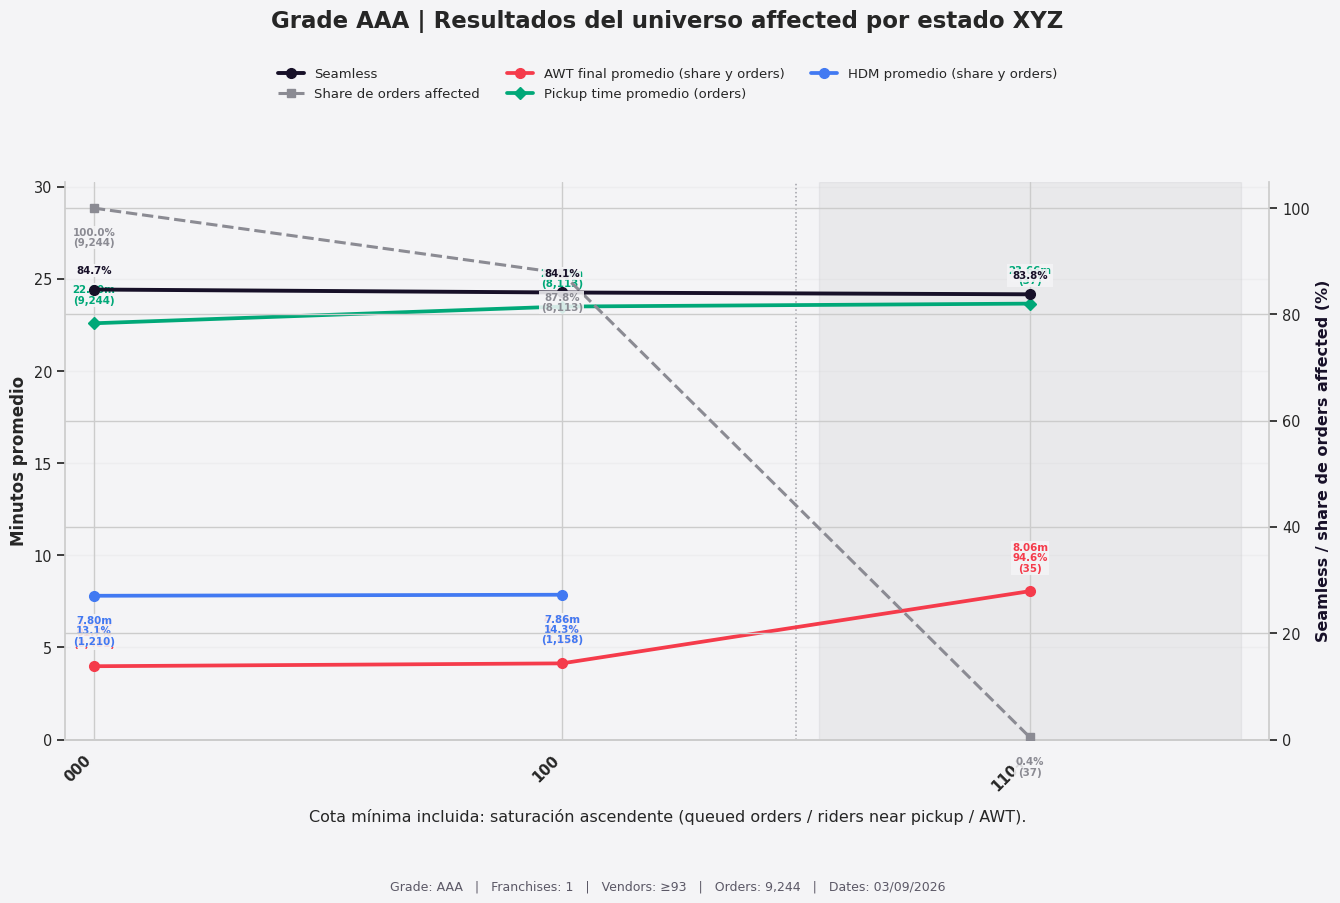

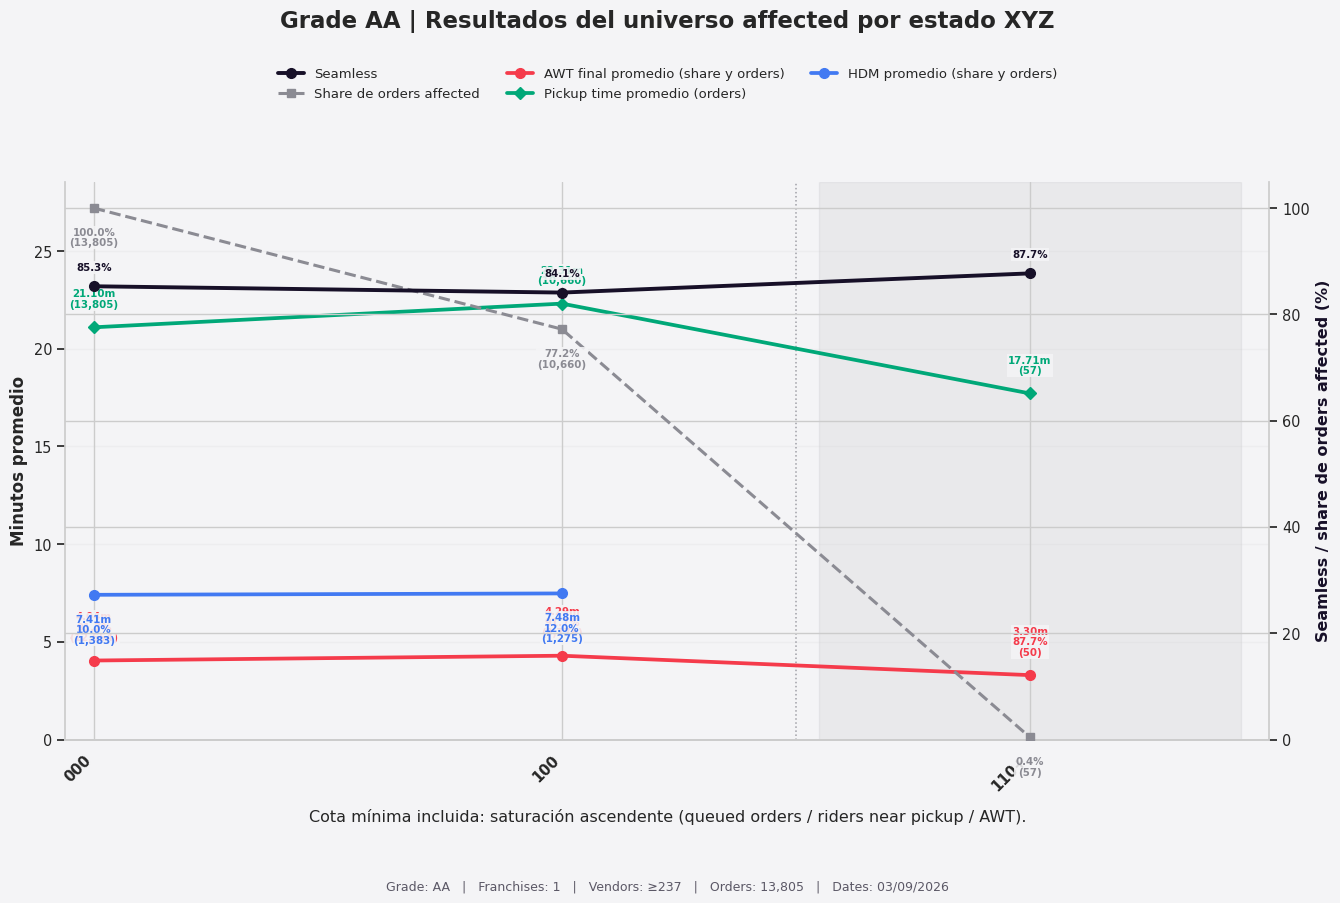

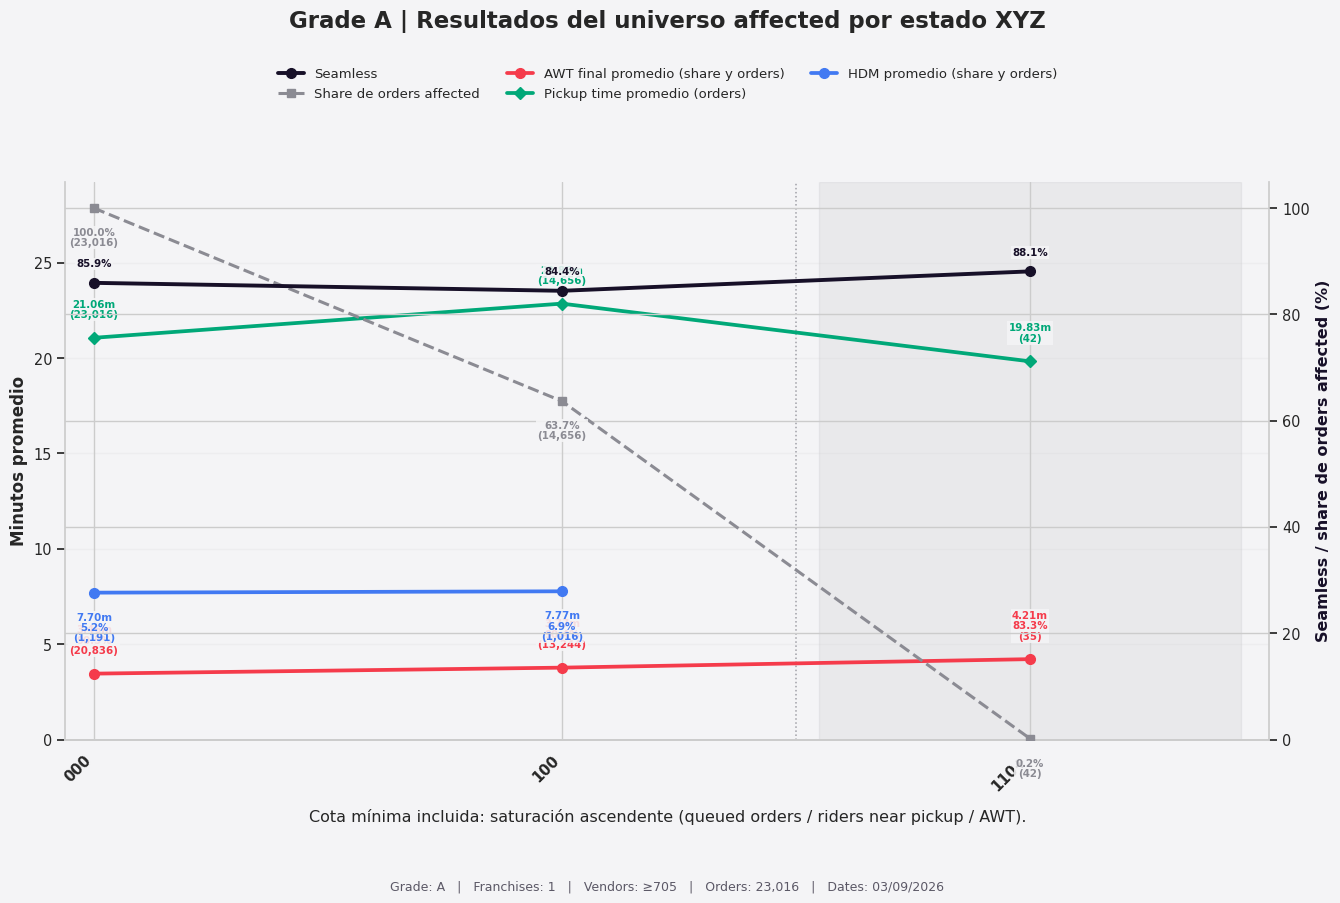

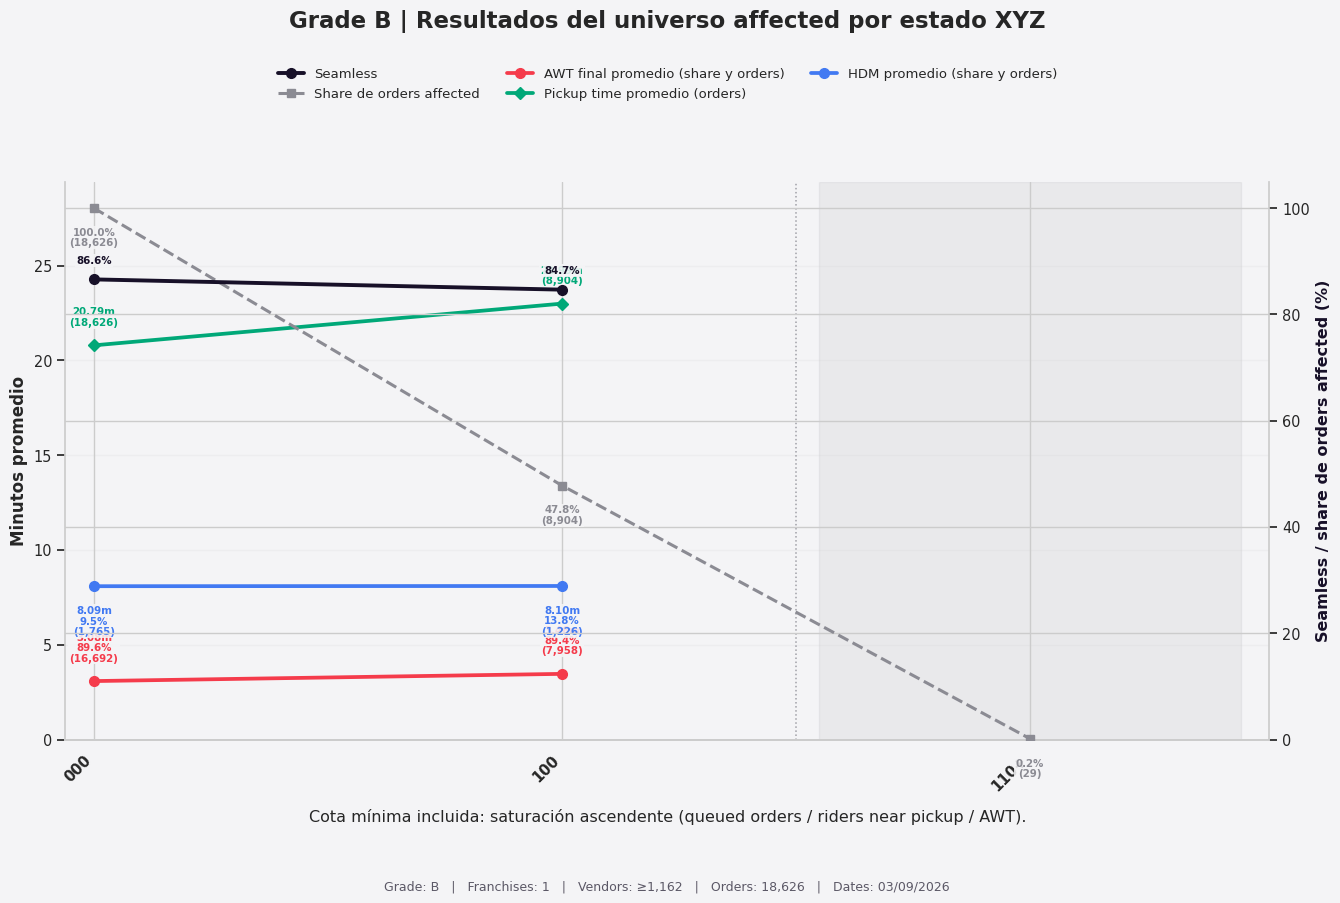

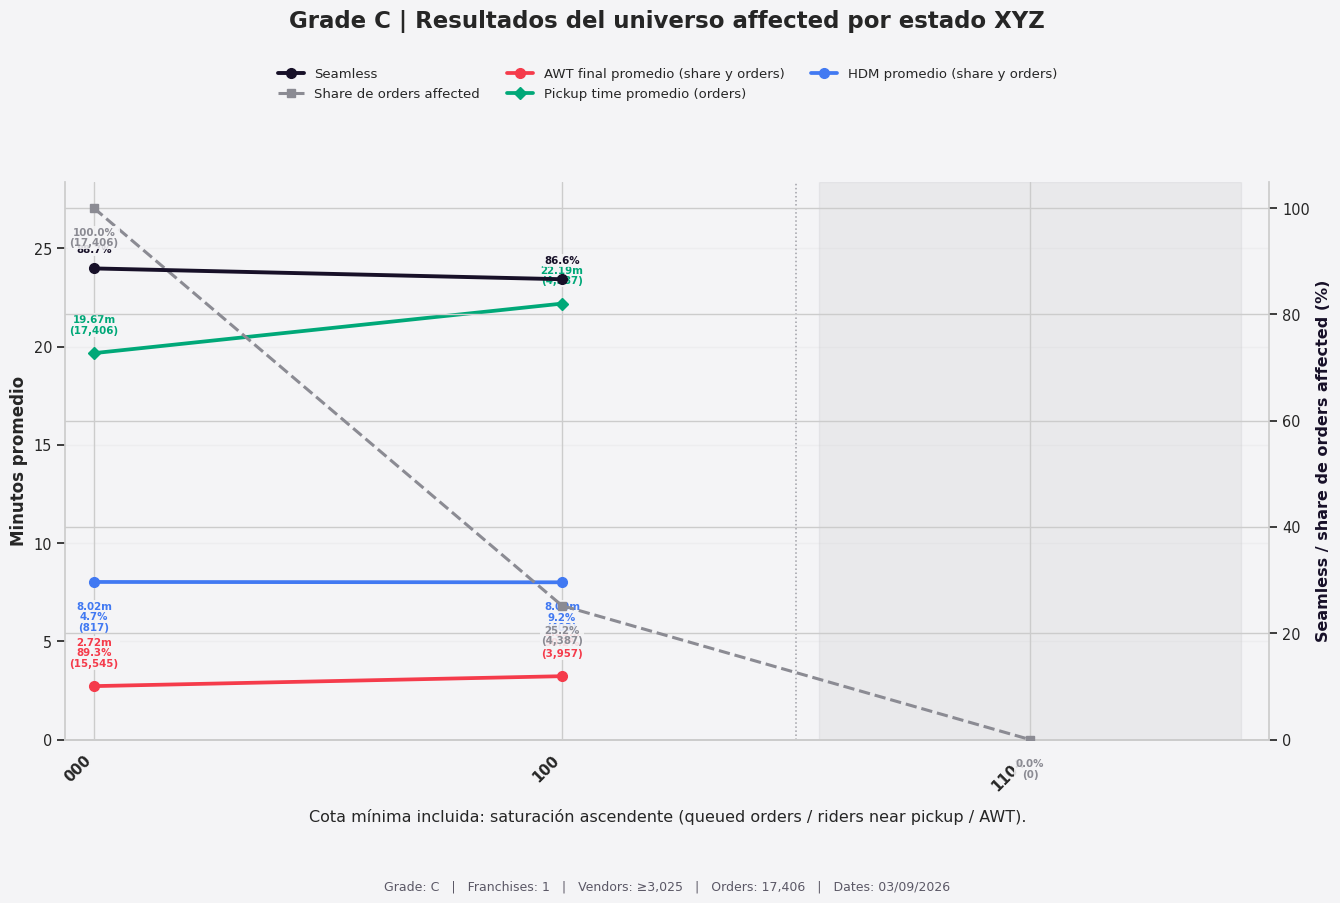

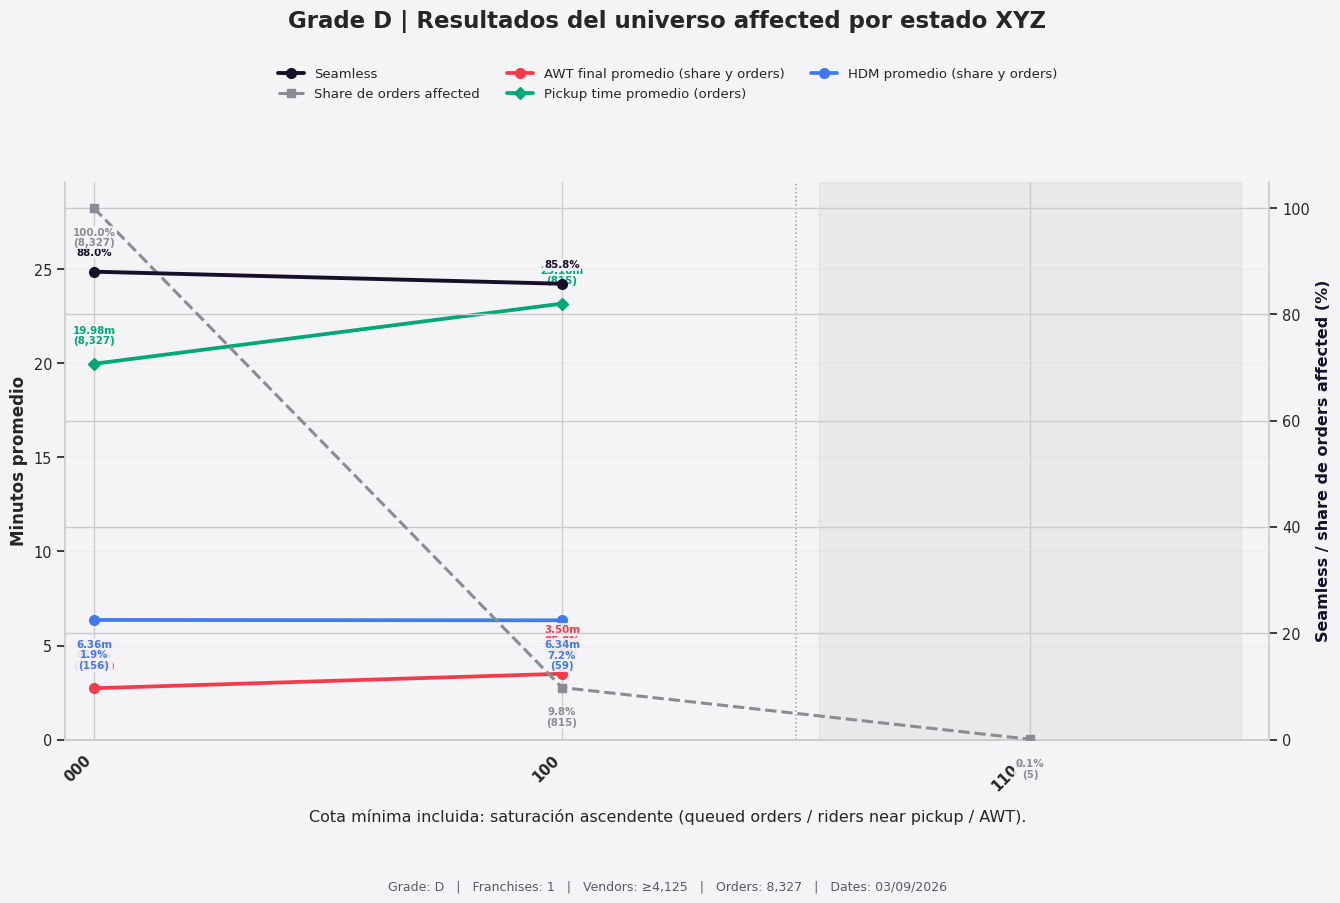

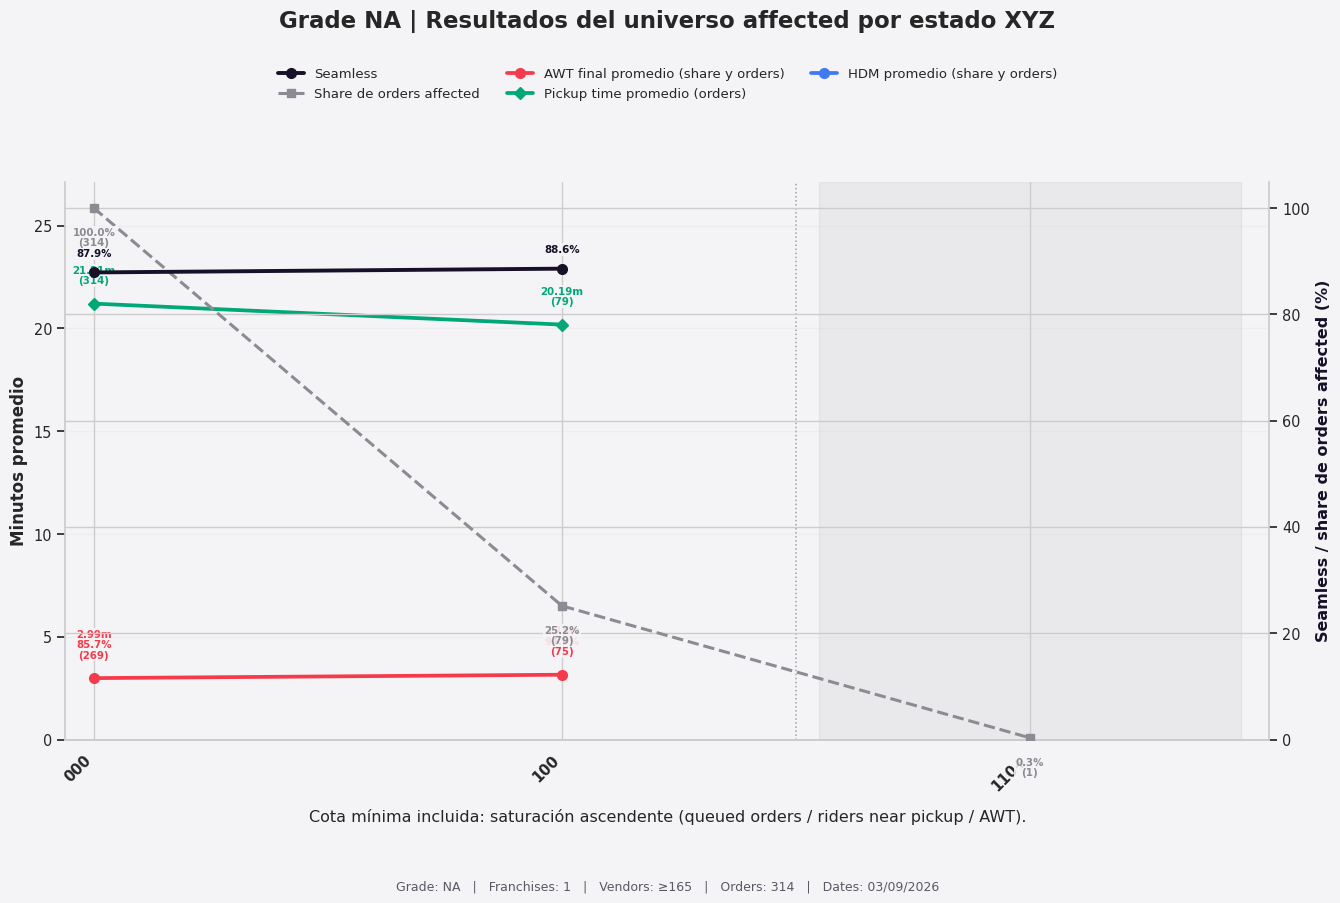

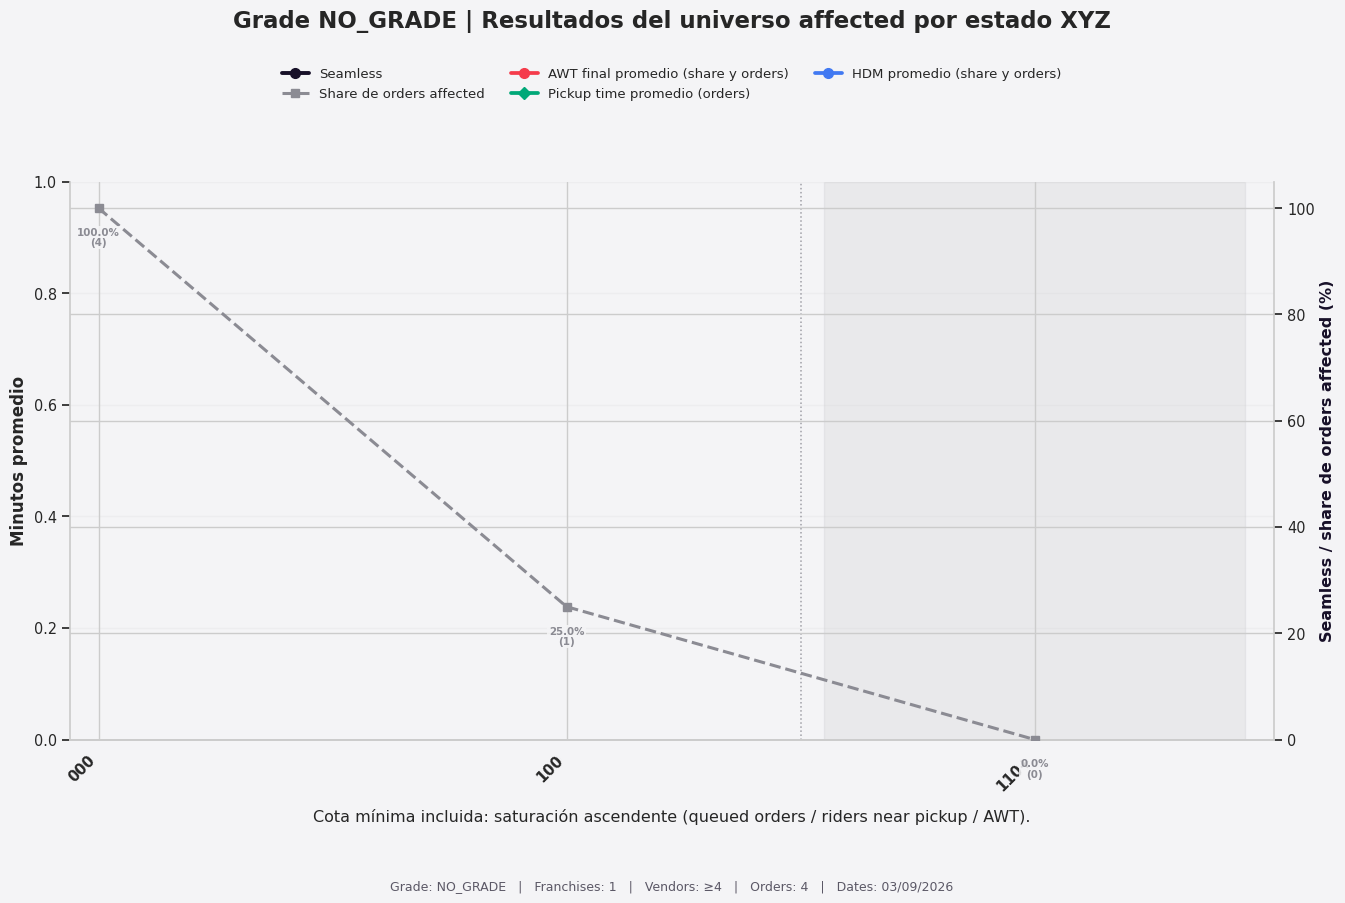

In [22]:
xyz_affected_summary, xyz_cutoffs = build_affected_xyz_summary(
    data=analysis_data,
    grades=grades_available,
    target_healthy_share_pct=TARGET_HEALTHY_ORDER_SHARE_PCT,
    max_points=AFFECTED_POINTS,
)

display(
    xyz_cutoffs.style.format({
        "target_healthy_share_pct": "{:.1f}%",
        "actual_healthy_share_pct": "{:.2f}%",
        "actual_affected_share_pct": "{:.2f}%",
        "affected_orders": "{:,.0f}",
    })
)

xyz_figures = plot_affected_curves(
    summary=xyz_affected_summary,
    title_text="Resultados del universo affected por estado XYZ",
    x_axis_text=(
        "Cota mínima incluida: saturación ascendente "
        "(queued orders / riders near pickup / AWT)."
    ),
    x_rotation=45,
)


## 6. Zoom-in por componente y grade

Cada gráfico usa cotas inclusivas entre `ZOOM_MIN_THRESHOLD` y `ZOOM_MAX_THRESHOLD` —por defecto, 0 a 9— y se muestra en orden **grade → componente**.

- `queued_orders >= X`, sin restringir riders ni AWT.
- `riders_near_pu >= Y`, sin restringir queued orders ni AWT.
- `max_awt_completed_minutes >= Z`, sin restringir queued orders ni riders.

El punto 0 representa el 100% del grade. Como cada universo está contenido en el anterior, el share de orders nunca puede subir.


In [23]:
zoom_summaries = {}
zoom_figures = {}

for component_column, component_info in COMPONENT_CONFIG.items():
    zoom_summaries[component_column] = (
        build_component_affected_summary(
            data=analysis_data,
            grades=grades_available,
            component_column=component_column,
            min_threshold=ZOOM_MIN_THRESHOLD,
            max_threshold=ZOOM_MAX_THRESHOLD,
        )
    )


# Orden de salida: grade → componente.
for grade in grades_available:
    display(Markdown(f"### Grade {grade}"))
    zoom_figures[grade] = {}

    for component_column, component_info in COMPONENT_CONFIG.items():
        component_figures = plot_affected_curves(
            summary=zoom_summaries[component_column],
            title_text=(
                f"Zoom-in affected por {component_info['short']}"
            ),
            x_axis_text=(
                f"{component_info['axis']}. "
                "Cada punto incluye esa cota y todos los superiores."
            ),
            x_rotation=0,
            grades_to_plot=[grade],
            footer_data=analysis_data,
        )

        zoom_figures[grade][component_column] = (
            component_figures.get(grade)
        )


Output hidden; open in https://colab.research.google.com to view.

## 7. Heatmaps ORA con una componente fija

Este bloque fija una componente del trigger y cruza las otras dos. El ejemplo inicial es **Grade AA + queued orders ≥ 1**.

- En modo `minimum`, la condición fija es una cota real de trigger (`orders >= 1`).
- En modo `exact`, se analiza únicamente el estado exacto (`orders == 1`) como diagnóstico.
- Cada celda aplica las tres condiciones con `AND` y contiene esa combinación y todos los estados superiores.
- El share affected se calcula contra **todas las orders del grade/franquicia seleccionado**, no contra la rebanada ya filtrada.
- El heatmap usa **Seamless como color** y cada celda anota Seamless, share/volumen affected, AWT final oficial, HDM y pickup time.

El AWT de cada celda es exactamente el mismo de los gráficos de línea: `awt_total_minutes / awt_orders`. Los intentos intermedios de reasignación no se incluyen.


In [24]:
def filter_ora_scope(data, grade="ALL", franchise="ALL"):
    scope = data.copy()

    if grade != "ALL":
        scope = scope[scope["grade"].eq(str(grade))].copy()

    if franchise != "ALL":
        scope = scope[
            scope["franchise_name"].eq(str(franchise))
        ].copy()

    if scope.empty:
        raise ValueError(
            "No hay datos para el grade y franchise seleccionados."
        )

    return scope


def build_ora_fixed_base(
    data,
    grade,
    franchise,
    fixed_component,
    fixed_value,
    fixed_mode="minimum",
):
    if fixed_component not in COMPONENT_CONFIG:
        raise ValueError(f"Componente desconocida: {fixed_component}")

    fixed_value = int(fixed_value)
    fixed_mode = str(fixed_mode).strip().lower()

    if fixed_value < 0:
        raise ValueError("La cota fija no puede ser negativa.")

    if fixed_mode not in {"minimum", "exact"}:
        raise ValueError("fixed_mode debe ser 'minimum' o 'exact'.")

    scope = filter_ora_scope(data, grade, franchise)

    if fixed_mode == "minimum":
        fixed_mask = scope[fixed_component].ge(fixed_value)
        operator = "≥"
    else:
        fixed_mask = scope[fixed_component].eq(fixed_value)
        operator = "="

    base = scope.loc[fixed_mask].copy()

    if base.empty:
        raise ValueError(
            "La condición fija no contiene estados ni orders."
        )

    if float(scope["total_orders"].sum()) <= 0:
        raise ValueError("El scope seleccionado no contiene orders.")

    if float(base["total_orders"].sum()) <= 0:
        raise ValueError("La condición fija no contiene orders.")

    scope_label = str(grade) if grade != "ALL" else "ALL"
    fixed_label = (
        f"{COMPONENT_CONFIG[fixed_component]['short']} "
        f"{operator} {fixed_value}"
    )

    metadata = {
        "grade": grade,
        "franchise": franchise,
        "scope_label": scope_label,
        "fixed_component": fixed_component,
        "fixed_value": fixed_value,
        "fixed_mode": fixed_mode,
        "fixed_label": fixed_label,
        "scope_orders": float(scope["total_orders"].sum()),
        "base_orders": float(base["total_orders"].sum()),
        "scope_state_seconds": float(scope["state_seconds"].sum()),
        "base_state_seconds": float(base["state_seconds"].sum()),
    }
    metadata["base_share_scope_pct"] = safe_scalar_ratio(
        metadata["base_orders"],
        metadata["scope_orders"],
        100,
    )

    return scope, base, metadata


def build_ora_combination_grid(
    scope,
    base,
    fixed_component,
    min_threshold=0,
    max_threshold=9,
):
    min_threshold = int(min_threshold)
    max_threshold = int(max_threshold)

    if min_threshold < 0 or max_threshold < min_threshold:
        raise ValueError(
            "El rango ORA debe cumplir 0 <= mínimo <= máximo."
        )

    free_components = [
        component
        for component in COMPONENT_CONFIG
        if component != fixed_component
    ]
    x_component, y_component = free_components

    base_orders = float(base["total_orders"].sum())
    scope_orders = float(scope["total_orders"].sum())
    scope_seconds = float(scope["state_seconds"].sum())
    rows = []

    for y_threshold in range(min_threshold, max_threshold + 1):
        for x_threshold in range(min_threshold, max_threshold + 1):
            cell_mask = (
                base[x_component].ge(x_threshold)
                & base[y_component].ge(y_threshold)
            )
            cell_data = base.loc[cell_mask]

            row = summarize_universe(
                cell_data,
                scope_orders,
                scope_seconds,
            )
            row.update({
                "x_component": x_component,
                "y_component": y_component,
                "x_threshold": x_threshold,
                "y_threshold": y_threshold,
                "orders_share_scope_pct": row["orders_share_pct"],
                "orders_share_fixed_pct": safe_scalar_ratio(
                    row["total_orders"],
                    base_orders,
                    100,
                ),
            })
            rows.append(row)

    return pd.DataFrame(rows), x_component, y_component


def build_conditioned_component_summary(
    scope,
    base,
    scope_label,
    component_column,
    min_threshold=0,
    max_threshold=9,
):
    """Cota de una componente dentro del trigger fijo; share vs scope."""

    scope_orders = float(scope["total_orders"].sum())
    scope_seconds = float(scope["state_seconds"].sum())
    rows = []

    for threshold in range(int(min_threshold), int(max_threshold) + 1):
        affected_data = base[
            base[component_column].ge(threshold)
        ]
        row = summarize_universe(
            affected_data,
            scope_orders,
            scope_seconds,
        )
        row.update({
            "grade": scope_label,
            "component": component_column,
            "display_order": threshold,
            "state_code": str(threshold),
            "minimum_component_value": threshold,
            "is_target_residual": False,
        })
        rows.append(row)

    return pd.DataFrame(rows)


def _heatmap_matrix(grid, metric):
    matrix = grid.pivot(
        index="y_threshold",
        columns="x_threshold",
        values=metric,
    )

    # 0 queda abajo y la saturación aumenta hacia arriba.
    return matrix.sort_index(ascending=False)


def _heatmap_annotations_all_metrics(grid):
    label_data = grid.copy()

    def metric_text(value):
        return f"{value:.2f}m" if pd.notna(value) else "–"

    def format_label(row):
        if row["total_orders"] <= 0:
            return ""

        seamless_text = (
            f'{row["seamless_pct"]:.1f}%'
            if pd.notna(row["seamless_pct"])
            else "–"
        )
        return (
            f"S {seamless_text}\n"
            f'O {row["orders_share_pct"]:.2f}% '
            f'({row["total_orders"]:,.0f})\n'
            f'AWT {metric_text(row["avg_awt_minutes"])}\n'
            f'HDM {metric_text(row["avg_hdm_minutes"])}\n'
            f'PU {metric_text(row["avg_pickup_time_minutes"])}'
        )

    label_data["label"] = label_data.apply(format_label, axis=1)
    return (
        label_data
        .pivot(
            index="y_threshold",
            columns="x_threshold",
            values="label",
        )
        .sort_index(ascending=False)
    )


def plot_ora_heatmaps(
    grid,
    x_component,
    y_component,
    metadata,
):
    """Un heatmap con todas las métricas y color basado en Seamless."""

    x_label = COMPONENT_CONFIG[x_component]["short"]
    y_label = COMPONENT_CONFIG[y_component]["short"]

    seamless_matrix = _heatmap_matrix(grid, "seamless_pct")
    annotations = (
        _heatmap_annotations_all_metrics(grid)
        .reindex_like(seamless_matrix)
    )

    finite_seamless = seamless_matrix.to_numpy(dtype=float)
    finite_seamless = finite_seamless[np.isfinite(finite_seamless)]

    if finite_seamless.size:
        color_min = max(0, float(finite_seamless.min()) - 1)
        color_max = min(100, float(finite_seamless.max()) + 1)
        if color_min >= color_max:
            color_min = max(0, color_min - 1)
            color_max = min(100, color_max + 1)
    else:
        color_min, color_max = 0, 100

    fig, axis = plt.subplots(figsize=(18, 14))
    fig.patch.set_facecolor(BACKGROUND)

    sns.heatmap(
        seamless_matrix,
        ax=axis,
        cmap="RdYlGn",
        vmin=color_min,
        vmax=color_max,
        annot=annotations,
        fmt="",
        mask=seamless_matrix.isna(),
        linewidths=0.6,
        linecolor="white",
        annot_kws={
            "fontsize": 8.8,
            "fontweight": "semibold",
            "linespacing": 1.25,
        },
        cbar_kws={"label": "Seamless (%)", "shrink": 0.82},
    )

    # Mejora el contraste del texto en los extremos del mapa de color.
    color_span = max(color_max - color_min, 1e-9)
    for text in axis.texts:
        x_position, y_position = text.get_position()
        row_position = int(round(y_position - 0.5))
        column_position = int(round(x_position - 0.5))
        value = seamless_matrix.iloc[row_position, column_position]

        if pd.isna(value):
            continue

        normalized_value = (float(value) - color_min) / color_span
        text.set_color(
            "white"
            if normalized_value <= 0.16 or normalized_value >= 0.84
            else "#25212B"
        )

    axis.set_title(
        "Seamless y métricas del universo affected",
        fontsize=16,
        fontweight="bold",
        pad=14,
    )
    axis.set_xlabel(
        f"{x_label}: cota mínima",
        fontsize=12,
        fontweight="bold",
    )
    axis.set_ylabel(
        f"{y_label}: cota mínima",
        fontsize=12,
        fontweight="bold",
    )
    axis.tick_params(axis="both", rotation=0, labelsize=10.5)

    fig.suptitle(
        (
            "Combinaciones ORA | "
            f"Grade {metadata['grade']} | "
            f"Franchise {metadata['franchise']} | "
            f"{metadata['fixed_label']}"
        ),
        fontsize=19,
        fontweight="bold",
        y=0.985,
    )
    fig.text(
        0.5,
        0.012,
        (
            "S = Seamless | O = share de todas las orders del scope "
            "(volumen) | AWT = promedio oficial sólo sobre orders con AWT | "
            "Cada celda aplica las tres cotas con AND."
        ),
        ha="center",
        fontsize=10.5,
        color="#5B5866",
    )
    fig.tight_layout(rect=[0.025, 0.035, 0.98, 0.955])
    plt.show()

    return fig


def style_ora_combination_table(
    grid,
    x_component,
    y_component,
):
    table = grid[[
        "x_threshold",
        "y_threshold",
        "total_orders",
        "orders_share_pct",
        "seamless_pct",
        "awt_orders",
        "awt_share_pct",
        "avg_awt_minutes",
        "pickup_time_orders",
        "avg_pickup_time_minutes",
        "hdm_orders",
        "hdm_share_pct",
        "avg_hdm_minutes",
    ]].copy()

    table = table.rename(columns={
        "x_threshold": (
            f"Cota {COMPONENT_CONFIG[x_component]['short']}"
        ),
        "y_threshold": (
            f"Cota {COMPONENT_CONFIG[y_component]['short']}"
        ),
        "total_orders": "Orders affected",
        "orders_share_pct": "Share orders affected (%)",
        "seamless_pct": "Seamless (%)",
        "awt_orders": "Orders con AWT",
        "awt_share_pct": "Cobertura AWT (%)",
        "avg_awt_minutes": "AWT final promedio (min)",
        "pickup_time_orders": "Orders con pickup time",
        "avg_pickup_time_minutes": "Pickup time promedio (min)",
        "hdm_orders": "Orders con HDM",
        "hdm_share_pct": "Share HDM (%)",
        "avg_hdm_minutes": "HDM promedio (min)",
    })

    return table.style.format({
        f"Cota {COMPONENT_CONFIG[x_component]['short']}": "{:,.0f}",
        f"Cota {COMPONENT_CONFIG[y_component]['short']}": "{:,.0f}",
        "Orders affected": "{:,.0f}",
        "Share orders affected (%)": "{:.2f}%",
        "Seamless (%)": "{:.2f}%",
        "Orders con AWT": "{:,.0f}",
        "Cobertura AWT (%)": "{:.2f}%",
        "AWT final promedio (min)": "{:.2f}",
        "Orders con pickup time": "{:,.0f}",
        "Pickup time promedio (min)": "{:.2f}",
        "Orders con HDM": "{:,.0f}",
        "Share HDM (%)": "{:.2f}%",
        "HDM promedio (min)": "{:.2f}",
    }, na_rep="–")


def render_ora_explorer(
    grade,
    franchise,
    fixed_component,
    fixed_value,
    fixed_mode,
    max_threshold,
):
    scope, base, metadata = build_ora_fixed_base(
        data=analysis_data,
        grade=grade,
        franchise=franchise,
        fixed_component=fixed_component,
        fixed_value=fixed_value,
        fixed_mode=fixed_mode,
    )

    grid, x_component, y_component = build_ora_combination_grid(
        scope=scope,
        base=base,
        fixed_component=fixed_component,
        min_threshold=ORA_MIN_THRESHOLD,
        max_threshold=max_threshold,
    )

    metadata_table = pd.DataFrame([{
        "Grade": metadata["grade"],
        "Franchise": metadata["franchise"],
        "Condición fija": metadata["fixed_label"],
        "Orders scope": metadata["scope_orders"],
        "Orders que cumplen condición fija": metadata["base_orders"],
        "Share condición fija / scope (%)": (
            metadata["base_share_scope_pct"]
        ),
        "Eje X": COMPONENT_CONFIG[x_component]["short"],
        "Eje Y": COMPONENT_CONFIG[y_component]["short"],
    }])
    display(metadata_table.style.format({
        "Orders scope": "{:,.0f}",
        "Orders que cumplen condición fija": "{:,.0f}",
        "Share condición fija / scope (%)": "{:.2f}%",
    }))

    conditional_zoom_figures = {}

    for component in [x_component, y_component]:
        summary = build_conditioned_component_summary(
            scope=scope,
            base=base,
            scope_label=metadata["scope_label"],
            component_column=component,
            min_threshold=ORA_MIN_THRESHOLD,
            max_threshold=max_threshold,
        )
        figures = plot_affected_curves(
            summary=summary,
            title_text=(
                f"Zoom-in condicionado por {metadata['fixed_label']} | "
                f"{COMPONENT_CONFIG[component]['short']}"
            ),
            x_axis_text=(
                f"{COMPONENT_CONFIG[component]['axis']}. "
                "Share respecto del grade/franchise completo."
            ),
            x_rotation=0,
            grades_to_plot=[metadata["scope_label"]],
            footer_data=scope,
        )
        conditional_zoom_figures[component] = figures.get(
            metadata["scope_label"]
        )

    heatmap_figure = plot_ora_heatmaps(
        grid=grid,
        x_component=x_component,
        y_component=y_component,
        metadata=metadata,
    )

    display(Markdown("### Tabla completa de combinaciones mostradas"))
    display(style_ora_combination_table(
        grid,
        x_component,
        y_component,
    ))

    return {
        "scope": scope,
        "base": base,
        "metadata": metadata,
        "grid": grid,
        "zoom_figures": conditional_zoom_figures,
        "heatmap_figure": heatmap_figure,
    }


In [25]:
try:
    import ipywidgets as widgets

    try:
        from google.colab import output as colab_output
        colab_output.enable_custom_widget_manager()
    except (ImportError, AttributeError):
        pass

    default_ora_grade = (
        ORA_DEFAULT_GRADE
        if ORA_DEFAULT_GRADE in grades_available
        else grades_available[0]
    )

    ora_grade_widget = widgets.Dropdown(
        options=["ALL"] + grades_available,
        value=default_ora_grade,
        description="Grade:",
        style={"description_width": "initial"},
    )
    ora_franchise_widget = widgets.Dropdown(
        options=["ALL"] + sorted(
            analysis_data["franchise_name"].unique().tolist()
        ),
        value=(
            ORA_DEFAULT_FRANCHISE
            if ORA_DEFAULT_FRANCHISE == "ALL"
            or ORA_DEFAULT_FRANCHISE
            in analysis_data["franchise_name"].unique()
            else "ALL"
        ),
        description="Franchise:",
        style={"description_width": "initial"},
    )
    ora_component_widget = widgets.Dropdown(
        options=[
            (info["short"], component)
            for component, info in COMPONENT_CONFIG.items()
        ],
        value=ORA_DEFAULT_FIXED_COMPONENT,
        description="Componente fija:",
        style={"description_width": "initial"},
    )
    ora_mode_widget = widgets.Dropdown(
        options=[("≥ cota", "minimum"), ("= exacto", "exact")],
        value=ORA_DEFAULT_FIXED_MODE,
        description="Modo:",
        style={"description_width": "initial"},
    )
    ora_fixed_value_widget = widgets.IntSlider(
        value=ORA_DEFAULT_FIXED_VALUE,
        min=0,
        max=max(
            ORA_MAX_THRESHOLD,
            int(analysis_data[[
                "queued_orders",
                "riders_near_pu",
                "max_awt_completed_minutes",
            ]].max().max()),
        ),
        step=1,
        description="Valor fijo:",
        continuous_update=False,
        style={"description_width": "initial"},
    )
    ora_max_widget = widgets.IntSlider(
        value=ORA_MAX_THRESHOLD,
        min=3,
        max=max(9, ORA_MAX_THRESHOLD),
        step=1,
        description="Máxima cota ejes:",
        continuous_update=False,
        style={"description_width": "initial"},
    )
    ora_button = widgets.Button(
        description="Actualizar ORA",
        button_style="primary",
        icon="refresh",
    )
    ora_output = widgets.Output()


    def update_ora(_=None):
        with ora_output:
            clear_output(wait=True)
            try:
                render_ora_explorer(
                    grade=ora_grade_widget.value,
                    franchise=ora_franchise_widget.value,
                    fixed_component=ora_component_widget.value,
                    fixed_value=ora_fixed_value_widget.value,
                    fixed_mode=ora_mode_widget.value,
                    max_threshold=ora_max_widget.value,
                )
            except ValueError as exc:
                print(exc)


    ora_button.on_click(update_ora)
    ora_controls = widgets.VBox([
        widgets.HBox([ora_grade_widget, ora_franchise_widget]),
        widgets.HBox([ora_component_widget, ora_mode_widget]),
        ora_fixed_value_widget,
        ora_max_widget,
        ora_button,
    ])

    display(ora_controls, ora_output)
    update_ora()

except ImportError:
    print(
        "ipywidgets no está disponible. "
        "Se ejecuta el ejemplo inicial sin controles."
    )
    ora_results = render_ora_explorer(
        grade=(
            ORA_DEFAULT_GRADE
            if ORA_DEFAULT_GRADE in grades_available
            else grades_available[0]
        ),
        franchise=ORA_DEFAULT_FRANCHISE,
        fixed_component=ORA_DEFAULT_FIXED_COMPONENT,
        fixed_value=ORA_DEFAULT_FIXED_VALUE,
        fixed_mode=ORA_DEFAULT_FIXED_MODE,
        max_threshold=ORA_MAX_THRESHOLD,
    )


Output()

## 7.1 Cubo ORA 3D por estado exacto

Cada esfera representa un **estado de saturación exacto** `(queued orders, riders near pickup, max AWT)`:

- **posición**: las tres componentes ORA del estado;
- **color**: Seamless del estado (rojo = menor, verde = mayor);
- **volumen de la esfera**: proporcional a la cantidad de orders generadas en ese estado.

Para conseguir esa equivalencia, el diámetro visual es proporcional a la raíz cúbica de `total_orders`. El hover muestra orders, share del scope, Seamless, AWT final oficial, HDM y pickup time. Este cubo no usa universos acumulados `>=`: cada order pertenece a un solo estado exacto, por lo que los volúmenes no se duplican entre puntos.

El cubo es interactivo: se puede rotar, hacer zoom y ocultar puntos desde la leyenda. Las cotas de los tres ejes se configuran por separado debajo.


In [26]:
# =========================================================
# CUBO ORA 3D
# =========================================================

try:
    import plotly.graph_objects as go
except ImportError as exc:
    raise ImportError(
        "Este bloque necesita Plotly. En Colab viene instalado; "
        "en local ejecuta: pip install plotly"
    ) from exc


# Scope inicial del cubo. Las cotas son inclusivas y sólo limitan
# la visualización; el share siempre se calcula contra todo el scope.
CUBE_GRADE = "AA"
CUBE_FRANCHISE = "ALL"
CUBE_MAX_QUEUED = 4
CUBE_MAX_RIDERS = 4
CUBE_MAX_AWT = 9
CUBE_MAX_MARKER_DIAMETER = 46

CUBE_STATE_COLUMNS = [
    "queued_orders",
    "riders_near_pu",
    "max_awt_completed_minutes",
]

CUBE_ADDITIVE_COLUMNS = [
    "total_orders",
    "seamless_orders",
    "awt_orders",
    "awt_total_minutes",
    "pickup_time_orders",
    "pickup_time_total_minutes",
    "hdm_orders",
    "hdm_total_minutes_added",
]


def _safe_vector_ratio(numerator, denominator, multiplier=1):
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    return multiplier * numerator.div(denominator.where(denominator.gt(0)))


def build_ora_cube_states(
    data,
    grade="AA",
    franchise="ALL",
    max_queued=9,
    max_riders=9,
    max_awt=9,
):
    """Agrega métricas por estado ORA exacto para el cubo 3D."""

    limits = {
        "queued_orders": int(max_queued),
        "riders_near_pu": int(max_riders),
        "max_awt_completed_minutes": int(max_awt),
    }

    if any(value < 0 for value in limits.values()):
        raise ValueError("Las cotas del cubo no pueden ser negativas.")

    scope = filter_ora_scope(data, grade, franchise)
    scope_orders = float(scope["total_orders"].sum())

    if scope_orders <= 0:
        raise ValueError("El scope seleccionado no contiene orders.")

    states = (
        scope.groupby(CUBE_STATE_COLUMNS, as_index=False)[
            CUBE_ADDITIVE_COLUMNS
        ]
        .sum()
    )

    in_cube = np.logical_and.reduce([
        states[component].between(0, limit, inclusive="both")
        for component, limit in limits.items()
    ])

    states = states.loc[
        in_cube & states["total_orders"].gt(0)
    ].copy()

    if states.empty:
        raise ValueError(
            "No hay estados con orders dentro de las cotas del cubo."
        )

    states["orders_share_pct"] = (
        100 * states["total_orders"] / scope_orders
    )
    states["seamless_pct"] = _safe_vector_ratio(
        states["seamless_orders"],
        states["total_orders"],
        100,
    )
    states["avg_awt_minutes"] = _safe_vector_ratio(
        states["awt_total_minutes"],
        states["awt_orders"],
    )
    states["avg_hdm_minutes"] = _safe_vector_ratio(
        states["hdm_total_minutes_added"],
        states["hdm_orders"],
    )
    states["avg_pickup_time_minutes"] = _safe_vector_ratio(
        states["pickup_time_total_minutes"],
        states["pickup_time_orders"],
    )

    metadata = {
        "grade": grade,
        "franchise": franchise,
        "scope_orders": scope_orders,
        "cube_orders": float(states["total_orders"].sum()),
        "limits": limits,
    }
    metadata["cube_share_scope_pct"] = (
        100 * metadata["cube_orders"] / scope_orders
    )

    return scope, states, metadata


def _cube_geometry(max_queued, max_riders, max_awt):
    """Devuelve vértices, caras y aristas del cubo transparente."""

    x0, x1 = -0.5, float(max_queued) + 0.5
    y0, y1 = -0.5, float(max_riders) + 0.5
    z0, z1 = -0.5, float(max_awt) + 0.5

    vertices = np.array([
        [x0, y0, z0],
        [x1, y0, z0],
        [x1, y1, z0],
        [x0, y1, z0],
        [x0, y0, z1],
        [x1, y0, z1],
        [x1, y1, z1],
        [x0, y1, z1],
    ])

    triangles = np.array([
        [0, 1, 2], [0, 2, 3],
        [4, 6, 5], [4, 7, 6],
        [0, 4, 5], [0, 5, 1],
        [1, 5, 6], [1, 6, 2],
        [2, 6, 7], [2, 7, 3],
        [3, 7, 4], [3, 4, 0],
    ])

    edge_pairs = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7),
    ]

    edge_x, edge_y, edge_z = [], [], []
    for start, end in edge_pairs:
        edge_x.extend([vertices[start, 0], vertices[end, 0], None])
        edge_y.extend([vertices[start, 1], vertices[end, 1], None])
        edge_z.extend([vertices[start, 2], vertices[end, 2], None])

    return vertices, triangles, edge_x, edge_y, edge_z


def plot_ora_cube(
    states,
    metadata,
    max_marker_diameter=46,
):
    """Dibuja el cubo 3D: color = Seamless; volumen = orders."""

    limits = metadata["limits"]
    vertices, triangles, edge_x, edge_y, edge_z = _cube_geometry(
        limits["queued_orders"],
        limits["riders_near_pu"],
        limits["max_awt_completed_minutes"],
    )

    # Plotly recibe el diámetro del marcador. Si diámetro ∝ orders^(1/3),
    # entonces el volumen de la esfera ∝ orders.
    max_orders = float(states["total_orders"].max())
    marker_diameter = (
        float(max_marker_diameter)
        * np.cbrt(states["total_orders"] / max_orders)
    )

    valid_seamless = states["seamless_pct"].dropna()
    if valid_seamless.empty:
        color_min, color_max = 0.0, 100.0
    else:
        color_min = float(valid_seamless.min())
        color_max = float(valid_seamless.max())
        if np.isclose(color_min, color_max):
            color_min = max(0.0, color_min - 0.5)
            color_max = min(100.0, color_max + 0.5)

    customdata = np.column_stack([
        states["total_orders"],
        states["orders_share_pct"],
        states["seamless_pct"],
        states["avg_awt_minutes"],
        states["avg_hdm_minutes"],
        states["avg_pickup_time_minutes"],
    ])

    figure = go.Figure()

    figure.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=triangles[:, 0],
        j=triangles[:, 1],
        k=triangles[:, 2],
        color="#6B7280",
        opacity=0.035,
        flatshading=True,
        hoverinfo="skip",
        showlegend=False,
        name="Cubo ORA",
    ))

    figure.add_trace(go.Scatter3d(
        x=edge_x,
        y=edge_y,
        z=edge_z,
        mode="lines",
        line={"color": "rgba(80, 86, 100, 0.42)", "width": 3},
        hoverinfo="skip",
        showlegend=False,
        name="Límites del cubo",
    ))

    figure.add_trace(go.Scatter3d(
        x=states["queued_orders"],
        y=states["riders_near_pu"],
        z=states["max_awt_completed_minutes"],
        mode="markers",
        name="Estado exacto",
        customdata=customdata,
        marker={
            "size": marker_diameter,
            "sizemode": "diameter",
            "sizemin": 2,
            "color": states["seamless_pct"],
            "colorscale": [
                [0.00, "#B2182B"],
                [0.50, "#FEE08B"],
                [1.00, "#08783E"],
            ],
            "cmin": color_min,
            "cmax": color_max,
            "opacity": 0.78,
            "line": {"color": "rgba(36, 40, 48, 0.45)", "width": 0.6},
            "colorbar": {
                "title": {"text": "Seamless (%)"},
                "thickness": 18,
                "len": 0.72,
            },
        },
        hovertemplate=(
            "<b>Estado exacto</b><br>"
            "Queued orders: %{x}<br>"
            "Riders near pickup: %{y}<br>"
            "Max AWT: %{z} min<br><br>"
            "Orders: %{customdata[0]:,.0f}<br>"
            "Share del scope: %{customdata[1]:.2f}%<br>"
            "Seamless: %{customdata[2]:.1f}%<br>"
            "AWT final oficial: %{customdata[3]:.2f} min<br>"
            "HDM: %{customdata[4]:.2f} min<br>"
            "Pickup time: %{customdata[5]:.2f} min"
            "<extra></extra>"
        ),
    ))

    grade_label = str(metadata["grade"])
    franchise_label = str(metadata["franchise"])
    cube_share = metadata["cube_share_scope_pct"]

    figure.update_layout(
        title={
            "text": (
                f"Cubo ORA | Grade {grade_label} | "
                f"Franchise {franchise_label}<br>"
                "<sup>Estado exacto · color = Seamless · "
                "volumen de esfera ∝ orders · "
                f"cubo visible = {cube_share:.2f}% de las orders del scope</sup>"
            ),
            "x": 0.5,
            "xanchor": "center",
        },
        height=820,
        margin={"l": 0, "r": 30, "t": 105, "b": 35},
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
        legend={"x": 0.01, "y": 0.99},
        scene={
            "xaxis": {
                "title": "Queued orders",
                "range": [-0.5, limits["queued_orders"] + 0.5],
                "dtick": 1,
            },
            "yaxis": {
                "title": "Riders near pickup",
                "range": [-0.5, limits["riders_near_pu"] + 0.5],
                "dtick": 1,
            },
            "zaxis": {
                "title": "Max AWT completed (min)",
                "range": [
                    -0.5,
                    limits["max_awt_completed_minutes"] + 0.5,
                ],
                "dtick": 1,
            },
            "aspectmode": "cube",
            "camera": {"eye": {"x": 1.55, "y": 1.55, "z": 1.25}},
            "bgcolor": "rgba(0,0,0,0)",
        },
    )

    figure.add_annotation(
        text=(
            "Cada esfera es un estado exacto. "
            "La esfera mayor corresponde al estado con más orders."
        ),
        x=0.5,
        y=0,
        xref="paper",
        yref="paper",
        yshift=-25,
        showarrow=False,
        font={"size": 12, "color": "#5B5866"},
    )

    figure.show()
    return figure


cube_scope, cube_states, cube_metadata = build_ora_cube_states(
    analysis_data,
    grade=CUBE_GRADE,
    franchise=CUBE_FRANCHISE,
    max_queued=CUBE_MAX_QUEUED,
    max_riders=CUBE_MAX_RIDERS,
    max_awt=CUBE_MAX_AWT,
)

ora_cube_figure = plot_ora_cube(
    cube_states,
    cube_metadata,
    max_marker_diameter=CUBE_MAX_MARKER_DIAMETER,
)

display(pd.DataFrame({
    "Scope orders": [cube_metadata["scope_orders"]],
    "Orders dentro del cubo": [cube_metadata["cube_orders"]],
    "Share del scope dentro del cubo (%)": [
        cube_metadata["cube_share_scope_pct"]
    ],
    "Estados exactos visibles": [len(cube_states)],
}).round(2))


,Scope orders,Orders dentro del cubo,Share del scope dentro del cubo (%),Estados exactos visibles
0,"13,805.00","11,684.00",84.64,25


## 8. Simulador healthy vs affected

El simulador usa la misma definición que todos los gráficos:

- **Affected**: `queued >= X AND riders >= Y AND AWT >= Z`.
- **Healthy**: `queued < X OR riders < Y OR AWT < Z`.

Así, para cualquier grade, `000` debe entregar **100% affected y 0% healthy**. El simulador incluye únicamente AWT final oficial, pickup time y HDM como resultados. Los intentos AWT intermedios quedan reservados para construir los hitos del estado.


In [27]:
def simulate_trigger_split(
    data,
    min_queued_orders,
    min_riders_near_pu,
    min_awt_minutes,
    grade="ALL",
    franchise="ALL",
):
    simulation_data = filter_ora_scope(
        data=data,
        grade=grade,
        franchise=franchise,
    )

    min_queued_orders = int(min_queued_orders)
    min_riders_near_pu = int(min_riders_near_pu)
    min_awt_minutes = int(min_awt_minutes)

    affected_mask = affected_xyz_mask(
        simulation_data,
        min_queued_orders,
        min_riders_near_pu,
        min_awt_minutes,
    )
    healthy_mask = ~affected_mask

    total_orders = float(simulation_data["total_orders"].sum())
    total_state_seconds = float(
        simulation_data["state_seconds"].sum()
    )

    if total_orders <= 0:
        raise ValueError("El universo seleccionado no contiene orders.")

    healthy_summary = summarize_universe(
        simulation_data.loc[healthy_mask],
        total_orders,
        total_state_seconds,
    )
    affected_summary = summarize_universe(
        simulation_data.loc[affected_mask],
        total_orders,
        total_state_seconds,
    )

    healthy_summary.update({
        "group": "Healthy",
        "rule": (
            f"q<{min_queued_orders} OR "
            f"riders<{min_riders_near_pu} OR "
            f"AWT<{min_awt_minutes}"
        ),
    })
    affected_summary.update({
        "group": "Affected",
        "rule": (
            f"q≥{min_queued_orders} AND "
            f"riders≥{min_riders_near_pu} AND "
            f"AWT≥{min_awt_minutes}"
        ),
    })

    result = pd.DataFrame([healthy_summary, affected_summary])

    if not np.isclose(result["orders_share_pct"].sum(), 100):
        raise AssertionError(
            "Healthy y affected no cierran al 100% de orders."
        )

    return result


SIMULATOR_COLUMNS = {
    "group": "Grupo",
    "rule": "Regla",
    "total_orders": "Orders",
    "orders_share_pct": "Share orders (%)",
    "state_time_share_pct": "Share tiempo (%)",
    "seamless_pct": "Seamless (%)",
    "slow_orders_pct": "Slow orders (%)",
    "avg_ept_minutes": "EPT promedio (min)",
    "avg_awt_minutes": "AWT final promedio (min)",
    "awt_share_pct": "Cobertura AWT final (%)",
    "avg_pickup_time_minutes": "Pickup time promedio (min)",
    "hdm_share_pct": "Share HDM (%)",
    "avg_hdm_minutes": "HDM promedio (min)",
    "awt10_attributed_pct": "AWT10 atribuido (%)",
}


def style_simulation_table(simulation_summary):
    table = (
        simulation_summary[list(SIMULATOR_COLUMNS)]
        .rename(columns=SIMULATOR_COLUMNS)
    )

    percent_columns = [
        column
        for column in table.columns
        if "(%)" in column
    ]
    minute_columns = [
        column
        for column in table.columns
        if "(min)" in column
    ]

    formats = {
        "Orders": "{:,.0f}",
    }
    formats.update({column: "{:.2f}" for column in percent_columns})
    formats.update({column: "{:.2f}" for column in minute_columns})

    return (
        table.style
        .format(formats, na_rep="–")
        .set_properties(**{"text-align": "center"})
        .set_properties(
            subset=["Regla"],
            **{"text-align": "left"},
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#27232F"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                ],
            }
        ])
    )


def plot_simulation_split(simulation_summary):
    order = ["Healthy", "Affected"]
    plot_data = (
        simulation_summary
        .set_index("group")
        .reindex(order)
    )
    group_colors = [COLORS["healthy"], COLORS["affected"]]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    fig.patch.set_facecolor(BACKGROUND)

    for axis in axes:
        axis.set_facecolor(BACKGROUND)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)

    bars = axes[0].bar(
        order,
        plot_data["orders_share_pct"],
        color=group_colors,
    )
    axes[0].set_title("Share de orders")
    axes[0].set_ylabel("%")
    axes[0].set_ylim(0, 105)
    axes[0].bar_label(bars, fmt="%.1f%%", padding=3)

    quality_metrics = {
        "Seamless": "seamless_pct",
        "Slow": "slow_orders_pct",
        "AWT10": "awt10_attributed_pct",
    }
    quality_frame = plot_data[list(quality_metrics.values())].T
    quality_frame.index = list(quality_metrics)
    quality_frame.plot(
        kind="bar",
        ax=axes[1],
        color=group_colors,
        width=0.72,
    )
    axes[1].set_title("Resultados porcentuales")
    axes[1].set_ylabel("%")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(title=None, frameon=False)

    minute_metrics = {
        "AWT final": "avg_awt_minutes",
        "Pickup": "avg_pickup_time_minutes",
        "HDM": "avg_hdm_minutes",
    }
    minute_frame = plot_data[list(minute_metrics.values())].T
    minute_frame.index = list(minute_metrics)
    minute_frame.plot(
        kind="bar",
        ax=axes[2],
        color=group_colors,
        width=0.72,
    )
    axes[2].set_title("Tiempos promedio")
    axes[2].set_ylabel("Minutos")
    axes[2].tick_params(axis="x", rotation=0)
    axes[2].legend(title=None, frameon=False)

    fig.suptitle(
        "Simulación del split healthy vs affected",
        fontsize=15,
        fontweight="bold",
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    return fig


In [28]:
def render_simulation(
    grade,
    franchise,
    min_queued_orders,
    min_riders_near_pu,
    min_awt_minutes,
):
    simulation_summary = simulate_trigger_split(
        data=analysis_data,
        min_queued_orders=min_queued_orders,
        min_riders_near_pu=min_riders_near_pu,
        min_awt_minutes=min_awt_minutes,
        grade=grade,
        franchise=franchise,
    )

    display(style_simulation_table(simulation_summary))
    plot_simulation_split(simulation_summary)

    return simulation_summary


try:
    import ipywidgets as widgets

    try:
        from google.colab import output as colab_output
        colab_output.enable_custom_widget_manager()
    except (ImportError, AttributeError):
        pass

    grade_widget = widgets.Dropdown(
        options=["ALL"] + grades_available,
        value="ALL",
        description="Grade:",
        style={"description_width": "initial"},
    )

    franchise_widget = widgets.Dropdown(
        options=["ALL"] + sorted(
            analysis_data["franchise_name"].unique().tolist()
        ),
        value="ALL",
        description="Franchise:",
        style={"description_width": "initial"},
    )

    queued_widget = widgets.IntSlider(
        value=min(
            SIM_DEFAULT_QUEUED_ORDERS,
            int(analysis_data["queued_orders"].max()),
        ),
        min=0,
        max=max(1, int(analysis_data["queued_orders"].max())),
        step=1,
        description="Min queued affected:",
        continuous_update=False,
        style={"description_width": "initial"},
    )

    riders_widget = widgets.IntSlider(
        value=min(
            SIM_DEFAULT_RIDERS_NEAR_PU,
            int(analysis_data["riders_near_pu"].max()),
        ),
        min=0,
        max=max(1, int(analysis_data["riders_near_pu"].max())),
        step=1,
        description="Min riders affected:",
        continuous_update=False,
        style={"description_width": "initial"},
    )

    awt_widget = widgets.IntSlider(
        value=min(
            SIM_DEFAULT_AWT_MINUTES,
            int(
                analysis_data[
                    "max_awt_completed_minutes"
                ].max()
            ),
        ),
        min=0,
        max=max(
            1,
            int(
                analysis_data[
                    "max_awt_completed_minutes"
                ].max()
            ),
        ),
        step=1,
        description="Min AWT affected:",
        continuous_update=False,
        style={"description_width": "initial"},
    )

    run_button = widgets.Button(
        description="Actualizar simulación",
        button_style="primary",
        icon="refresh",
    )
    simulator_output = widgets.Output()


    def update_simulator(_=None):
        with simulator_output:
            clear_output(wait=True)
            try:
                render_simulation(
                    grade=grade_widget.value,
                    franchise=franchise_widget.value,
                    min_queued_orders=queued_widget.value,
                    min_riders_near_pu=riders_widget.value,
                    min_awt_minutes=awt_widget.value,
                )
            except ValueError as exc:
                print(exc)


    run_button.on_click(update_simulator)

    controls = widgets.VBox([
        widgets.HBox([grade_widget, franchise_widget]),
        queued_widget,
        riders_widget,
        awt_widget,
        run_button,
    ])

    display(controls, simulator_output)
    update_simulator()

except ImportError:
    print(
        "ipywidgets no está disponible. "
        "Se ejecuta la simulación inicial sin controles."
    )
    simulation_summary = render_simulation(
        grade="ALL",
        franchise="ALL",
        min_queued_orders=SIM_DEFAULT_QUEUED_ORDERS,
        min_riders_near_pu=SIM_DEFAULT_RIDERS_NEAR_PU,
        min_awt_minutes=SIM_DEFAULT_AWT_MINUTES,
    )


Output()